In [1]:
# Primero, instala PyTorch con CUDA 11.8
!pip install torch==2.0.1+cu118 torchvision torchaudio -f https://download.pytorch.org/whl/torch_stable.html

# Instalar los paquetes de PyTorch Geometric que coinciden con CUDA 11.8
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.0.1+cu118.html
!pip install pyg-lib -f https://data.pyg.org/whl/torch-2.0.1+cu118.html
!pip install torch-geometric


Looking in links: https://download.pytorch.org/whl/torch_stable.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 GB 668.6 kB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 MB 10.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 MB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 96.3 MB/s eta 0:00:00
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 106.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 MB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 MB 11.7 MB/s 

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random
from random import randint
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx  # Asegúrate de importar to_networkx
%matplotlib inline
np.random.seed(42)
random.seed(42)

In [3]:
import torch

torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
import os.path as osp
import sys
from torch_geometric.nn import Node2Vec

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [6]:
from torch_geometric.datasets import DeezerEurope

# Directorio donde se guardará el dataset
dataset_path = './data/DeezerEurope'

# Cargar el dataset
dataset = DeezerEurope(root=dataset_path)

# Acceder al primer grafo del dataset
data = dataset[0]

print(data)


Data(x=[28281, 128], edge_index=[2, 185504], y=[28281])


Processing...
Done!


Particion de datos

In [7]:
torch.manual_seed(0)
num_nodes = data.num_nodes
data.train_mask = torch.rand(num_nodes) < 0.6    # 60% para entrenamiento
data.val_mask = (torch.rand(num_nodes) < 0.2) & ~data.train_mask  # 20% para validación
data.test_mask = ~data.train_mask & ~data.val_mask  # 20% para prueba

In [ ]:
print("Número de nodos:", data.num_nodes)
print("Número de aristas:", data.num_edges)
print("Atributos de nodos:", data.x)
print("Etiquetas:", data.y)


Número de nodos: 28281
Número de aristas: 185504
Atributos de nodos: tensor([[-0.2231, -0.1776, -0.1713,  ..., -0.2608, -0.3070,  0.3880],
        [-0.2231,  0.1626,  0.2821,  ..., -0.2608, -0.2337, -0.0955],
        [-0.2231, -0.1776,  5.0181,  ..., -0.2608, -0.3070, -0.0955],
        ...,
        [-0.2231, -0.1776, -0.1713,  ..., -0.2608, -0.3070, -0.0955],
        [-0.2231, -0.1776, -0.1713,  ..., -0.1293, -0.2427, -0.0955],
        [-0.2231, -0.1361, -0.1556,  ..., -0.2608, -0.3070, -0.0955]])
Etiquetas: tensor([0, 0, 0,  ..., 0, 1, 1])


In [ ]:
# Acceder a las features de todos los nodos
node_features = data.x

# Ver todas las features del primer nodo
print("Features del primer nodo:", node_features[0])

# También puedes ver las dimensiones de las features
print("Dimensiones de las features (nodos x características):", node_features.shape)


Features del primer nodo: tensor([-0.2231, -0.1776, -0.1713, -0.2358, -0.2845, -0.2306, -0.1045, -0.1622,
        -0.2499, -0.1942, -0.2930, -0.3135, -0.2304, -0.2104, -0.2717, -0.1618,
        -0.2831, -0.1753, -0.2698, -0.3308, -0.0301, -0.2505, -0.1414, -0.2307,
        -0.1881, -0.2917, -0.0285, -0.0309, -0.3196, -0.1795, -0.2118, -0.2536,
        -0.3220, -0.2838, -0.3155, -0.2465, -0.0624, -0.2904, -0.2627, -0.3150,
        -0.0497, -0.2389, -0.1537, -0.1239, -0.0772, -0.2715, -0.1155, -0.2484,
        -0.0638, -0.2790, -0.2728, -0.2059, -0.2907, -0.0349, -0.2600, -0.2942,
        -0.2757, -0.2625, -0.3712, -0.1056, -0.1000, -0.2394,  3.7313, -0.2853,
        -0.2868, -0.3708, -0.2434, -0.3040, -0.2261, -0.0218, 12.4039, -0.3654,
        -0.1827, -0.4465, -0.3023, -0.2669,  4.3738,  2.6410, -0.2442, -0.0479,
        -0.2852, -0.2217, -0.1578, -0.0217, -0.2984, -0.3206, -0.0274, -0.3182,
        -0.3071, -0.2375, -0.2309, -0.1892, -0.3230, -0.2510, -0.2317, -0.2390,
        -0.392

In [ ]:
data = dataset[0]

# Convertir el grafo a un objeto de NetworkX
G = to_networkx(data, to_undirected=True)


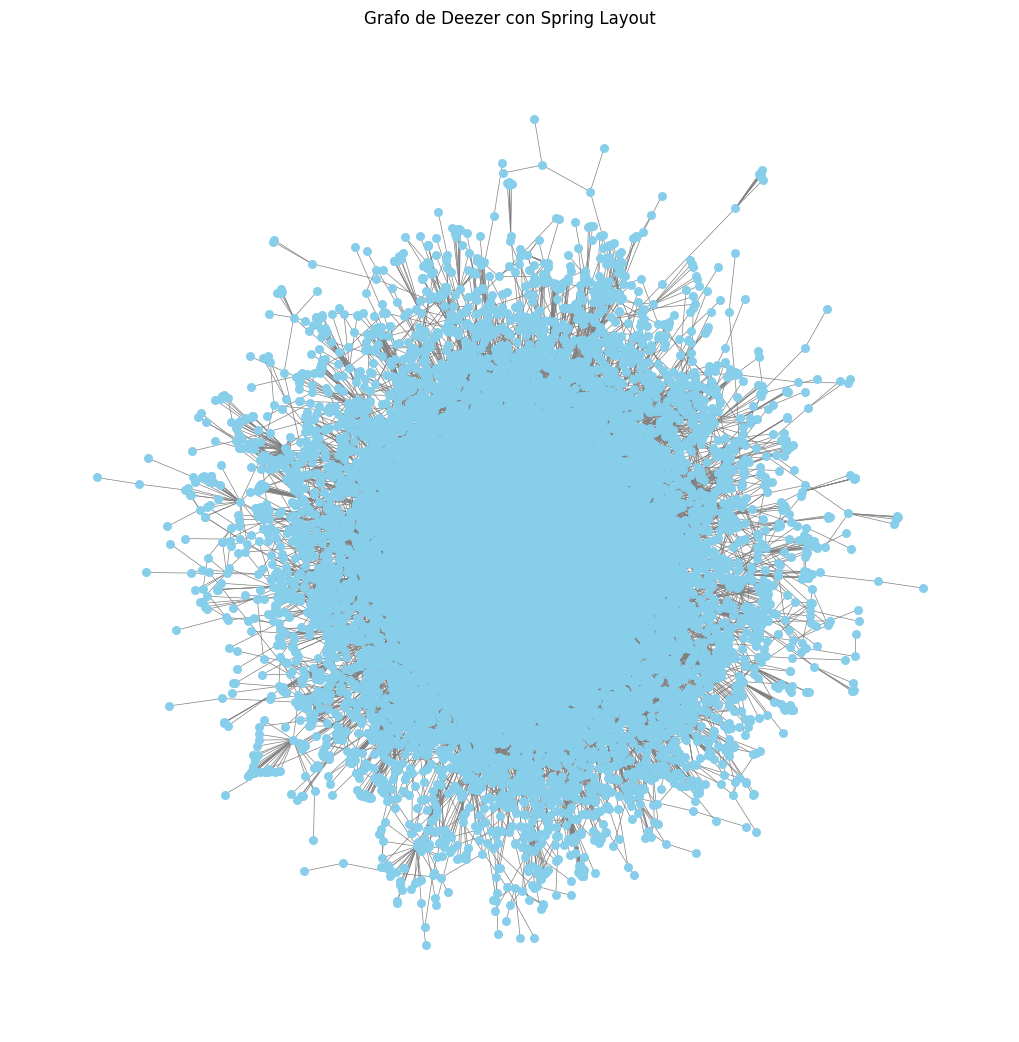

In [ ]:
# Dibuja el grafo usando spring layout
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, iterations=15,seed=42)  # Seed para una disposición consistente
nx.draw(G, pos, with_labels=False, node_size=30, node_color="skyblue", edge_color="gray", width=0.5)
plt.title("Grafo de Deezer con Spring Layout")
plt.show()


Agregar colores a las etiquetas y exportar para verlo en gephi

In [ ]:
# Crear un diccionario de colores basado en las etiquetas de clase
class_colors = {0: 'red', 1: 'blue'}
node_colors = [class_colors[int(data.y[node])] for node in range(data.num_nodes)]

# Asignar etiquetas de clase como atributo del nodo
for node in G.nodes:
    G.nodes[node]['class'] = int(data.y[node])

# Exportar a GEXF para Gephi
nx.write_gexf(G, 'deezer_europe.gexf')



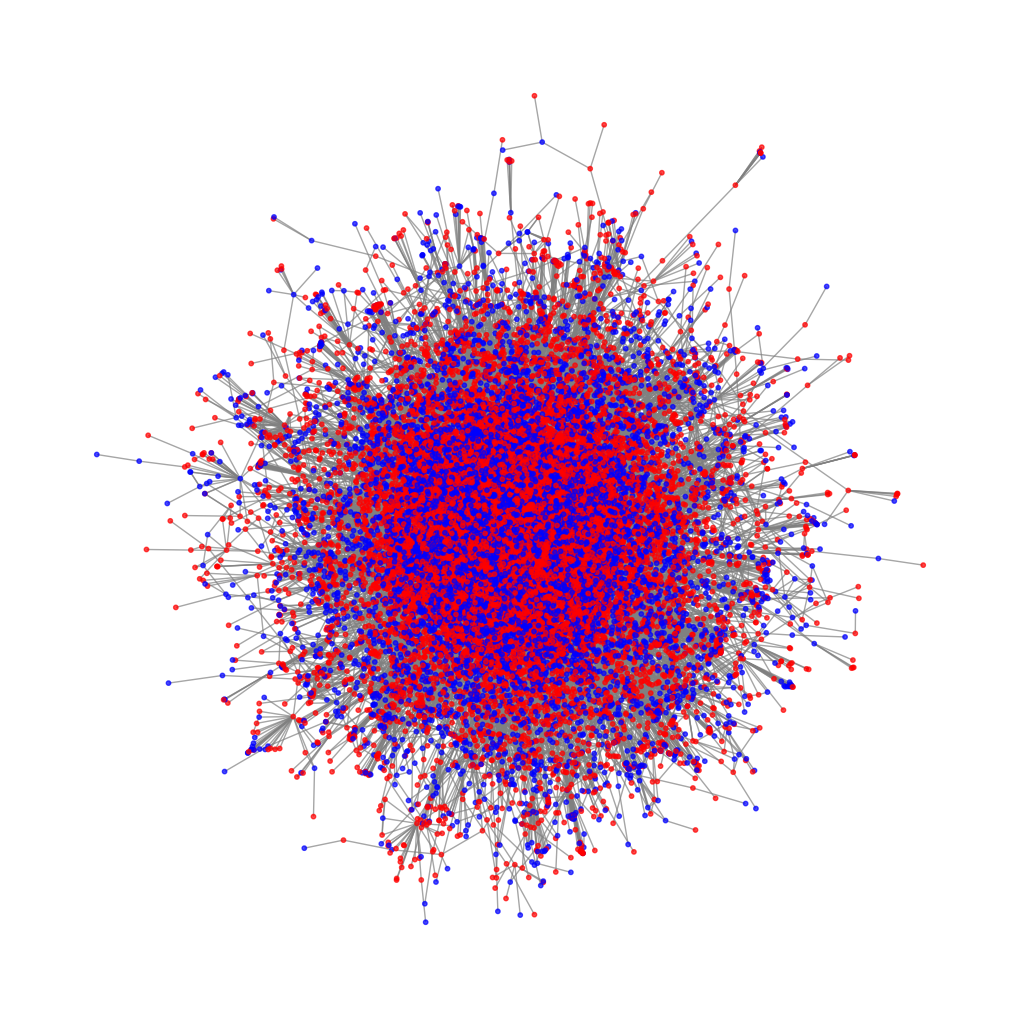

In [ ]:
# Opcional: Visualizar el grafo Demorado
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, iterations=15,seed=42)
nx.draw(G, pos, node_color=node_colors, node_size=10, edge_color="gray", alpha=0.7)
plt.show()

Imprime grafo los nodos con mayor grado de centralidad


In [ ]:
degree_centrality = nx.centrality.degree_centrality(
    G
)  # save results in a variable to use again
(sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True))[:8]

[(867, 0.006082036775106082),
 (396, 0.005374823196605374),
 (1878, 0.005127298444130127),
 (24904, 0.004137199434229137),
 (5989, 0.0039603960396039604),
 (24069, 0.0038896746817538895),
 (17963, 0.0033946251768033945),
 (23143, 0.0033239038189533236)]

In [ ]:
# Guardar en las siguientes variables, para posteriormente poder hacer lo de la red de egos.
top_nodes = sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True)[:8]
top_ego_nodes = [node for node, centrality in top_nodes]

Text(0, 0.5, 'Counts')

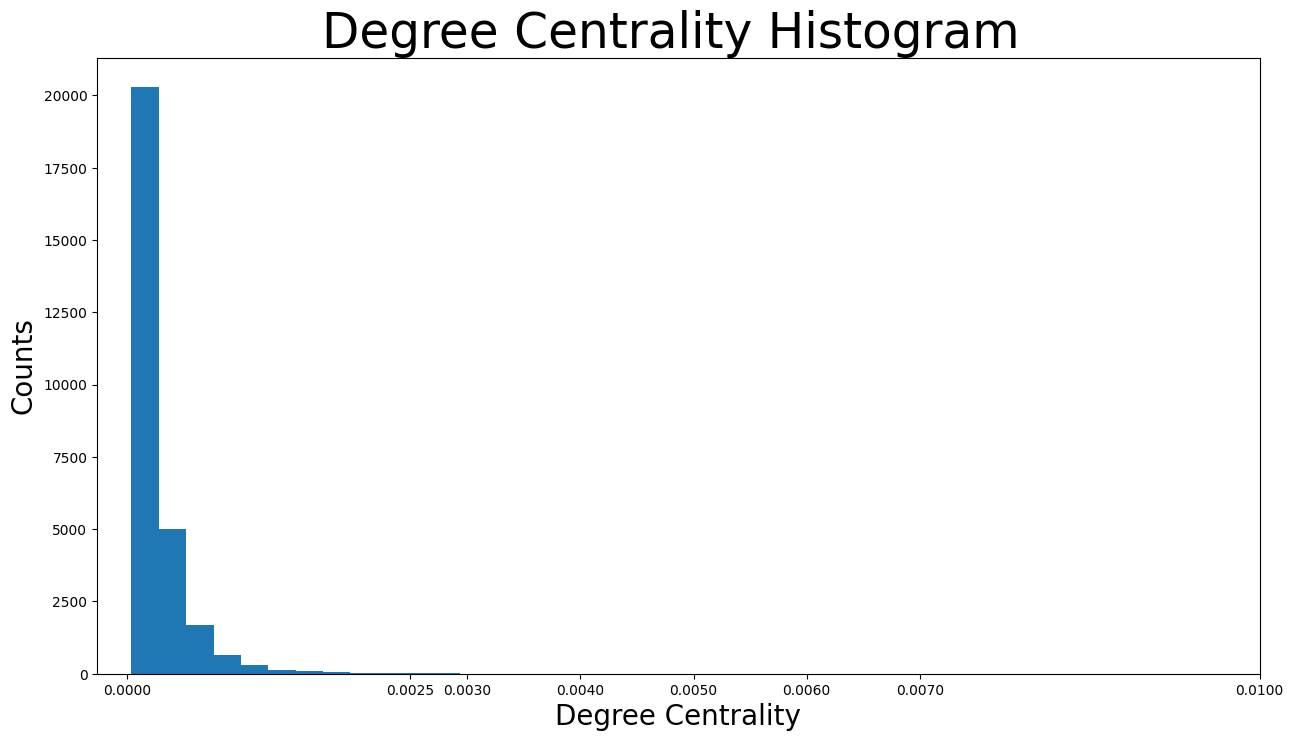

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(degree_centrality.values(), bins=25)
plt.xticks(ticks=[0, 0.0025, 0.003, 0.004, 0.005, 0.006,0.007,0.01])  # set the x axis ticks
plt.title("Degree Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Degree Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

(-1.2066288155317306,
 1.1745222967863083,
 -1.0307078248262405,
 1.1452679520845415)

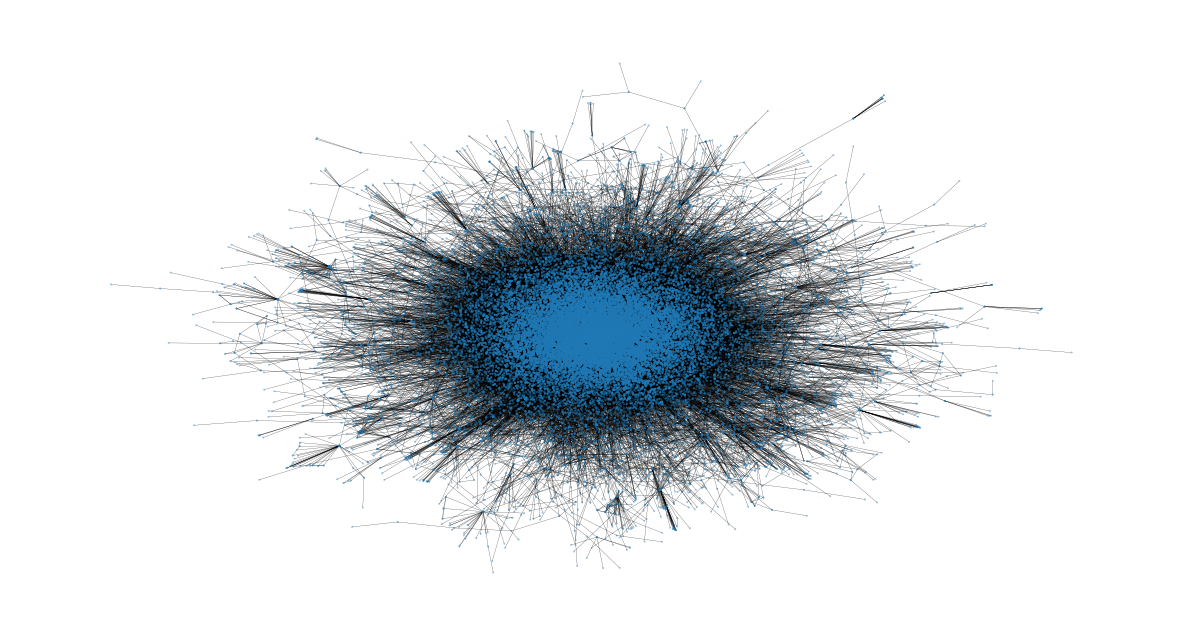

In [ ]:
node_size = [
    v * 1000 for v in degree_centrality.values()
]  # set up nodes size for a nice graph representation
plt.figure(figsize=(15, 8))
nx.draw_networkx(G, pos=pos, node_size=node_size, with_labels=False, width=0.15)
plt.axis("off")

Red de ego de cada nodo con mayor centralidad

In [ ]:
from collections import Counter

Proporción de clases en la red de ego del nodo 867:
- Clase 1: 0.71
- Clase 0: 0.29
Proporción de clases en la red de ego del nodo 396:
- Clase 0: 0.62
- Clase 1: 0.38
Proporción de clases en la red de ego del nodo 1878:
- Clase 1: 0.79
- Clase 0: 0.21
Proporción de clases en la red de ego del nodo 24904:
- Clase 0: 0.60
- Clase 1: 0.40
Proporción de clases en la red de ego del nodo 5989:
- Clase 0: 0.58
- Clase 1: 0.42
Proporción de clases en la red de ego del nodo 24069:
- Clase 0: 0.41
- Clase 1: 0.59
Proporción de clases en la red de ego del nodo 17963:
- Clase 1: 0.35
- Clase 0: 0.65
Proporción de clases en la red de ego del nodo 23143:
- Clase 0: 0.68
- Clase 1: 0.32


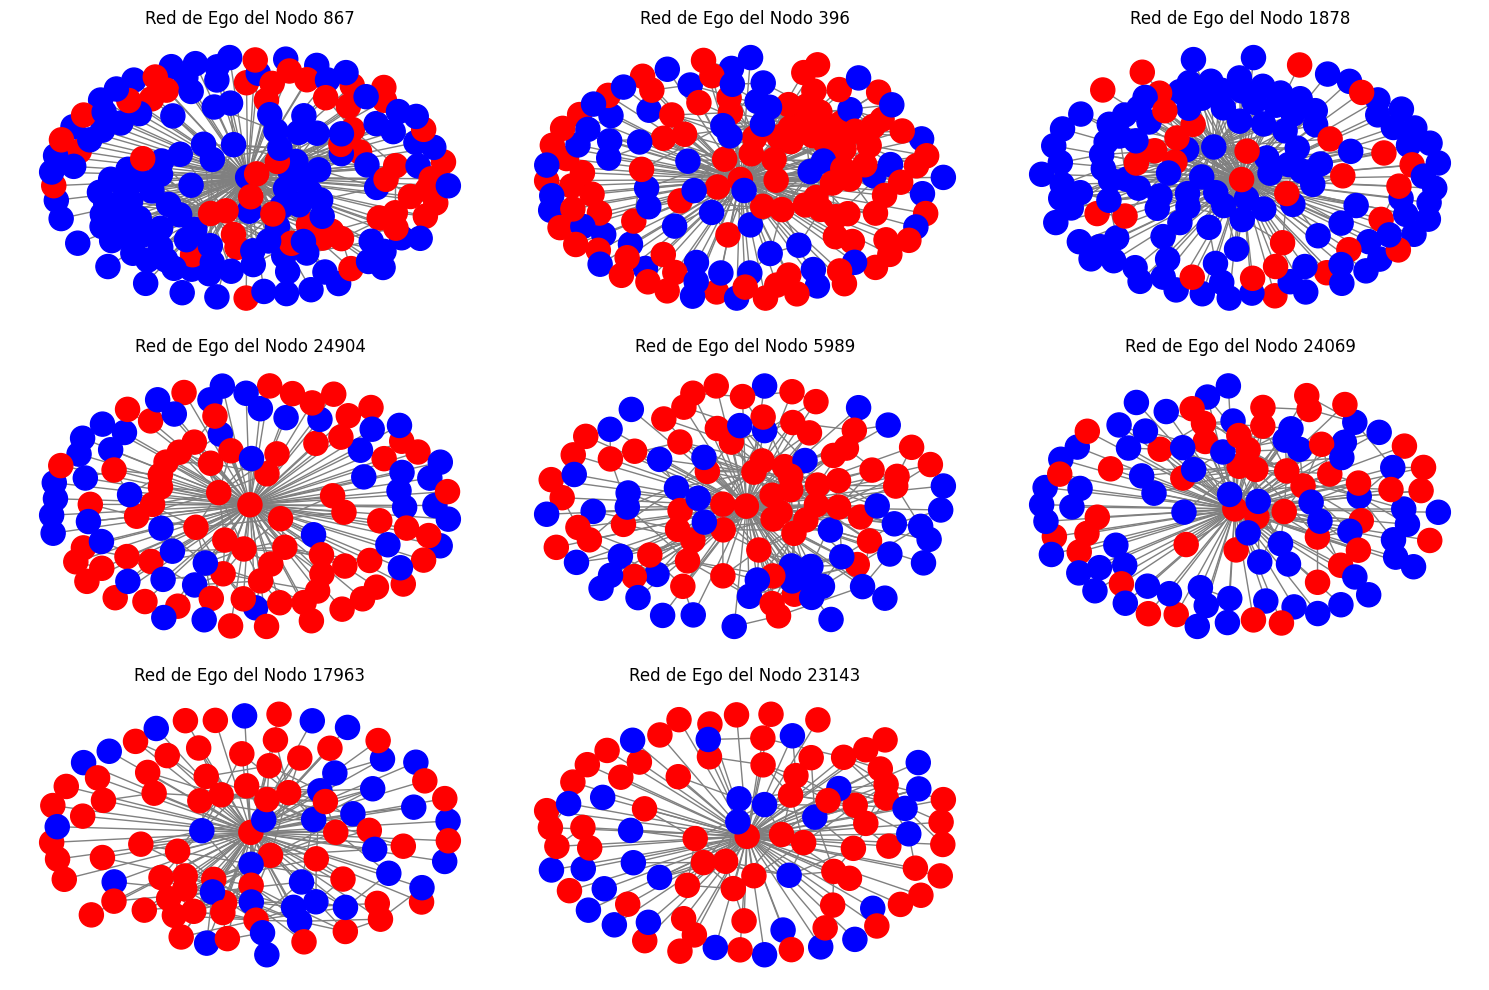

In [ ]:
plt.figure(figsize=(15, 10))
for i, ego in enumerate(top_ego_nodes, 1):
    # Crear la red de ego para el nodo
    ego_graph = nx.ego_graph(G, ego)

    # Asignar colores a los nodos de la red de ego según la clase
    ego_node_colors = [class_colors[G.nodes[node]['class']] for node in ego_graph.nodes]

    # Calcular proporción de clases
    class_counts = Counter(G.nodes[node]['class'] for node in ego_graph.nodes)
    total_nodes = sum(class_counts.values())
    proportions = {cls: count / total_nodes for cls, count in class_counts.items()}

    # Imprimir proporción de clases
    print(f"Proporción de clases en la red de ego del nodo {ego}:")
    for cls, proportion in proportions.items():
        print(f"- Clase {cls}: {proportion:.2f}")

    plt.subplot(3, 3, i)  # Organizar en una cuadrícula de 3x3
    nx.draw(ego_graph, with_labels=False, node_color=ego_node_colors, edge_color="gray", node_size=300)
    plt.title(f"Red de Ego del Nodo {ego}")
plt.tight_layout()
plt.show()

### Metricas del grafo

In [ ]:
# Print information about the dataset
print(f'Dataset: {dataset}')
print('-------------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.x.shape[0]}')
print(f'Number of unique features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print information about the graph
print(f'\nGraph:')
print('------')
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

Dataset: DeezerEurope()
-------------------
Number of graphs: 1
Number of nodes: 28281
Number of unique features: 128
Number of classes: 2

Graph:
------
Edges are directed: False
Graph has isolated nodes: False
Graph has loops: False


Encontrar el nodo con mayor conexiones

In [ ]:
# Calcular el grado de cada nodo
degrees = dict(G.degree())

# Encontrar el nodo con el mayor grado
max_degree_node = max(degrees, key=degrees.get)
max_degree = degrees[max_degree_node]

print(f"El nodo con el mayor grado es {max_degree_node} con un grado de {max_degree}.")

El nodo con el mayor grado es 867 con un grado de 172.


Promedio de grado por nodo

In [ ]:
np.mean([d for _, d in G.degree()])

6.559315441462466

## Modelo 1 - Node To Vec with Pytorch Aletorio p=1 y q=1

---



In [14]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
#

cuda


In [9]:
# Declarar el modelo Node2Vec Aleatorio
model = Node2Vec(
    data.edge_index,
    embedding_dim=100,    # Equivalente a vector_size
    walk_length=10,       # Equivalente a window
    context_size=10,      # Ventana de contexto
    walks_per_node=80,    # Número de recorridos para cada nodo (equivalente a workers en gensim)
    num_negative_samples=1, # Sin jerarquía de softmax en PyTorch Geometric
    p=1.0,
    q=1.0,
    sparse=True,
).to(device)

In [10]:
num_workers = 4 if sys.platform == 'linux' else 0
loader = model.loader(batch_size=128, shuffle=True, num_workers=num_workers) # this needed to calculate loss funtion (positive random walks and negative random walks)
optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=0.01)

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:560: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [11]:
# Generar las representaciones de nodos (embeddings)
z = model().detach().cpu().numpy()

# Crear etiquetas (basadas en las clases del grafo)
labels = data.y.cpu().numpy()

# Crear máscaras de entrenamiento, validación y prueba
num_nodes = data.num_nodes
torch.manual_seed(1)  # Fijar semilla para reproducibilidad

# Dividir los nodos en 70% para entrenamiento, 15% para validación, y 15% para prueba
perm = torch.randperm(num_nodes)
train_size = int(0.7 * num_nodes)
val_size = int(0.15 * num_nodes)

# Crear máscaras
train_mask = perm[:train_size]
val_mask = perm[train_size:train_size + val_size]
test_mask = perm[train_size + val_size:]

# Dividir los datos usando las máscaras
X_train, y_train = z[train_mask], labels[train_mask]
X_val, y_val = z[val_mask], labels[val_mask]
X_test, y_test = z[test_mask], labels[test_mask]

# Entrenar el clasificador RandomForest
clf = RandomForestClassifier(random_state=0)
clf.fit(X_train, y_train)

# Evaluar la precisión en los conjuntos de validación y prueba
y_val_pred = clf.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print(f'Validation accuracy = {val_acc*100:.2f}%')

y_test_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f'Test accuracy = {test_acc*100:.2f}%')

Validation accuracy = 54.81%
Test accuracy = 54.75%


In [12]:
def train():
    model.train()
    total_loss = 0
    for pos_rw, neg_rw in loader:
        optimizer.zero_grad()
        loss = model.loss(pos_rw.to(device), neg_rw.to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [13]:
@torch.no_grad() # -> Context-manager that disables gradient calculation. Computational cost and efficiency
def test():
    model.eval()
    z = model()
    acc = model.test(
        train_z=z[data.train_mask],
        train_y=data.y[data.train_mask],
        test_z=z[data.test_mask],
        test_y=data.y[data.test_mask],
        max_iter=150,
    )
    return acc

In [15]:
for epoch in range(1, 101):
    loss = train()
    acc = test()
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Acc: {acc:.4f}')

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:560: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch: 001, Loss: 6.8223, Acc: 0.5450


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:560: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch: 002, Loss: 4.4022, Acc: 0.5459


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:560: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


...

Epoch: 098, Loss: 0.9233, Acc: 0.5535


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:560: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch: 099, Loss: 0.9233, Acc: 0.5508


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:560: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch: 100, Loss: 0.9231, Acc: 0.5490


## Modelo 2 - GraphNeuralNetworks-NodeFeatures

In [ ]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch
#!pip install -q torch-scatter~=2.1.0 torch-sparse~=0.6.16 torch-cluster~=1.6.0 torch-spline-conv~=1.2.1 torch-geometric==2.2.0 -f https://data.pyg.org/whl/torch-{torch.__version__}.html
import optuna
from torch.nn import Linear
import torch.nn.functional as F

torch.manual_seed(0)

torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df_x = pd.DataFrame(data.x.numpy())
df_x['label'] = pd.DataFrame(data.y)
df_x

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,label
0,-0.223109,-0.177567,-0.171293,-0.235823,-0.284484,-0.230583,-0.104463,-0.162166,-0.249902,-0.194182,...,-0.240088,-0.174856,-0.327307,-0.302367,-0.269416,-0.024521,-0.260842,-0.307027,0.388035,0
1,-0.223109,0.162604,0.282057,-0.232282,3.818546,-0.259265,-0.104463,0.021555,1.453015,0.368591,...,-0.240088,-0.174856,-0.327307,-0.302367,3.820402,-0.096065,-0.260842,-0.233692,-0.095544,0
2,-0.223109,-0.177567,5.018122,-0.207325,-0.284484,-0.185022,-0.104463,-0.117579,-0.249902,-0.194182,...,-0.042116,-0.174856,-0.327307,-0.302367,-0.269416,-0.096065,-0.260842,-0.307027,-0.095544,0
3,-0.032303,-0.177567,-0.171293,-0.235823,-0.284484,-0.223115,-0.104463,4.757999,-0.249902,-0.194182,...,-0.240088,-0.174856,-0.327307,-0.302367,-0.269416,-0.096065,-0.260842,-0.307027,-0.095544,1
4,-0.223109,-0.177567,-0.171293,-0.235823,-0.284484,-0.259265,-0.104463,-0.162166,-0.249902,-0.194182,...,-0.240088,-0.174856,-0.327307,-0.302367,-0.269416,-0.096065,-0.260842,-0.307027,-0.095544,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28276,0.382963,-0.177567,-0.134661,-0.235823,-0.284484,-0.259265,-0.104463,-0.162166,-0.249902,-0.194182,...,-0.220015,1.277081,-0.327307,-0.302367,-0.265161,-0.096065,-0.260842,-0.307027,-0.095544,0
28277,3.633471,-0.177567,-0.171293,-0.235823,-0.284484,-0.259265,-0.104463,1.448882,0.139322,-0.194182,...,-0.240088,-0.174856,3.032435,-0.302367,4.781408,-0.096065,-0.253147,-0.307027,-0.095544,1
28278,-0.223109,-0.177567,-0.171293,-0.235823,-0.284484,-0.259265,-0.104463,-0.162166,-0.249902,-0.194182,...,-0.240088,-0.174856,-0.327307,-0.302367,-0.269416,-0.096065,-0.260842,-0.307027,-0.095544,0
28279,-0.223109,-0.177567,-0.171293,-0.235823,-0.277491,-0.259265,-0.104463,2.813498,-0.249902,-0.194182,...,-0.240088,-0.174856,-0.327307,-0.302367,-0.269416,-0.096065,-0.129325,-0.242732,-0.095544,1


In [ ]:
torch.manual_seed(0)
from torch.nn import Linear
import torch.nn.functional as F


def accuracy(y_pred, y_true):
    """Calculate accuracy."""
    return torch.sum(y_pred == y_true) / len(y_true)

In [ ]:
class MLP(torch.nn.Module):
    """Multilayer Perceptron para Clasificación Binaria"""
    def __init__(self, dim_in, dim_h, dim_out=1):
        super().__init__()
        self.linear1 = Linear(dim_in, dim_h)
        self.linear2 = Linear(dim_h, dim_out)

    def forward(self, x):
        x = self.linear1(x)
        x = torch.relu(x)
        x = self.linear2(x)
        return torch.sigmoid(x)  # Usamos sigmoid para salida binaria en [0,1]

    def fit(self, data, epochs, lr, weight_decay):
        # Para clasificación binaria, usamos BCELoss
        criterion = torch.nn.BCELoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=weight_decay)

        self.train()
        for epoch in range(epochs + 1):
            optimizer.zero_grad()
            out = self(data.x).squeeze()  # .squeeze() para remover dimensiones extra
            loss = criterion(out[data.train_mask], data.y[data.train_mask].float())

            # Precisión usando umbral de 0.5 para clasificación binaria
            acc = accuracy((out[data.train_mask] > 0.5).float(), data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            # Imprimir cada 20 épocas
            if epoch % 20 == 0:
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask].float())
                val_acc = accuracy((out[data.val_mask] > 0.5).float(), data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def validate(self, data):
        self.eval()
        out = self(data.x).squeeze()
        val_loss = F.binary_cross_entropy(out[data.val_mask], data.y[data.val_mask].float())
        val_acc = accuracy((out[data.val_mask] > 0.5).float(), data.y[data.val_mask])
        return val_loss.item(), val_acc

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x).squeeze()
        acc = accuracy((out[data.test_mask] > 0.5).float(), data.y[data.test_mask])
        return acc

Uso de Optuna

In [ ]:
# Definimos la función de objetivo para Optuna
def objective(trial):
    # Sugerimos hiperparámetros
    dim_h = trial.suggest_int("dim_h", 8, 128)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-5, 1e-2)

    # Creamos el modelo con los hiperparámetros propuestos
    model = MLP(dim_in=dataset.num_features, dim_h=dim_h, dim_out=1)

    # Entrenamos el modelo
    model.fit(data, epochs=50, lr=lr, weight_decay=weight_decay)

    # Validamos el modelo y obtenemos la pérdida de validación
    val_loss, val_acc = model.validate(data)

    # Retornamos la pérdida de validación como métrica para minimizar
    return val_loss

# Ejecutamos Optuna para encontrar los mejores hiperparámetros
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# Imprimimos los mejores hiperparámetros encontrados
#print("Best hyperparameters:", study.best_params)

# Entrenamos el modelo final con los mejores hiperparámetros
best_params = study.best_params
best_model = MLP(dim_in=dataset.num_features, dim_h=best_params["dim_h"], dim_out=1)
best_model.fit(data, epochs=100, lr=best_params["lr"], weight_decay=best_params["weight_decay"])

# Probamos el modelo final en el conjunto de prueba
acc = best_model.test(data)
print(f'\nMLP test accuracy: {acc*100:.2f}%')

[I 2024-11-02 22:53:12,583] A new study created in memory with name: no-name-3fc68197-fef3-48ea-b033-4d1c2fbde912
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14152\2155349585.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14152\2155349585.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-5, 1e-2)


Epoch   0 | Train Loss: 0.698 | Train Acc: 52.64% | Val Loss: 0.70 | Val Acc: 51.24%
Epoch  20 | Train Loss: 0.638 | Train Acc: 63.71% | Val Loss: 0.65 | Val Acc: 62.31%
Epoch  40 | Train Loss: 0.619 | Train Acc: 65.60% | Val Loss: 0.63 | Val Acc: 64.21%


[I 2024-11-02 22:53:13,955] Trial 0 finished with value: 0.6254879832267761 and parameters: {'dim_h': 102, 'lr': 0.0006480212321312305, 'weight_decay': 0.0006142499210230664}. Best is trial 0 with value: 0.6254879832267761.


Epoch   0 | Train Loss: 0.705 | Train Acc: 45.38% | Val Loss: 0.71 | Val Acc: 45.61%
Epoch  20 | Train Loss: 0.665 | Train Acc: 61.53% | Val Loss: 0.67 | Val Acc: 61.01%
Epoch  40 | Train Loss: 0.644 | Train Acc: 63.47% | Val Loss: 0.65 | Val Acc: 62.49%


[I 2024-11-02 22:53:15,036] Trial 1 finished with value: 0.6450517177581787 and parameters: {'dim_h': 71, 'lr': 0.00034241471888551023, 'weight_decay': 0.0017905023962049814}. Best is trial 0 with value: 0.6254879832267761.


...

Epoch   0 | Train Loss: 0.706 | Train Acc: 43.73% | Val Loss: 0.71 | Val Acc: 44.21%
Epoch  20 | Train Loss: 0.689 | Train Acc: 54.80% | Val Loss: 0.69 | Val Acc: 54.12%
Epoch  40 | Train Loss: 0.676 | Train Acc: 60.24% | Val Loss: 0.68 | Val Acc: 57.90%


[I 2024-11-02 22:54:03,949] Trial 48 finished with value: 0.6722188591957092 and parameters: {'dim_h': 99, 'lr': 0.0001072000190140013, 'weight_decay': 0.0070634967560441915}. Best is trial 41 with value: 0.6087926030158997.


Epoch   0 | Train Loss: 0.710 | Train Acc: 49.49% | Val Loss: 0.71 | Val Acc: 48.45%
Epoch  20 | Train Loss: 0.588 | Train Acc: 67.75% | Val Loss: 0.61 | Val Acc: 64.70%
Epoch  40 | Train Loss: 0.541 | Train Acc: 71.18% | Val Loss: 0.63 | Val Acc: 64.84%


[I 2024-11-02 22:54:05,681] Trial 49 finished with value: 0.643353283405304 and parameters: {'dim_h': 126, 'lr': 0.00821208044852634, 'weight_decay': 5.1905328569360235e-05}. Best is trial 41 with value: 0.6087926030158997.


Epoch   0 | Train Loss: 0.692 | Train Acc: 54.84% | Val Loss: 0.69 | Val Acc: 53.94%
Epoch  20 | Train Loss: 0.598 | Train Acc: 66.92% | Val Loss: 0.61 | Val Acc: 64.75%
Epoch  40 | Train Loss: 0.575 | Train Acc: 68.54% | Val Loss: 0.61 | Val Acc: 64.39%
Epoch  60 | Train Loss: 0.556 | Train Acc: 70.32% | Val Loss: 0.61 | Val Acc: 65.11%
Epoch  80 | Train Loss: 0.541 | Train Acc: 71.30% | Val Loss: 0.62 | Val Acc: 64.66%
Epoch 100 | Train Loss: 0.530 | Train Acc: 72.26% | Val Loss: 0.62 | Val Acc: 65.29%

MLP test accuracy: 65.10%


In [ ]:
# Imprimimos solo los mejores hiperparámetros finales
print("\nBest hyperparameters found by Optuna:")
print("Hidden Layer Size (dim_h):", study.best_params["dim_h"])
print("Learning Rate (lr):", study.best_params["lr"])
print("Weight Decay:", study.best_params["weight_decay"])


Best hyperparameters found by Optuna:
Hidden Layer Size (dim_h): 113
Learning Rate (lr): 0.00573901605397608
Weight Decay: 0.004679402615605212


### Modelo 2.1 - Node Features + Node2Vec

In [ ]:
# Parámetros de Node2Vec
embedding_dim = 112  # Dimensión de los embeddings de los nodos
walk_length = 26
context_size = 12
walks_per_node = 7
p = 10
q = 1

In [ ]:
# Inicializar y entrenar el modelo Node2Vec
node2vec = Node2Vec(data.edge_index, embedding_dim=embedding_dim, walk_length=walk_length,
                    context_size=context_size, walks_per_node=walks_per_node, p=p, q=q, sparse=True)
node2vec = node2vec.to('cuda' if torch.cuda.is_available() else 'cpu')
node2vec.train()

# Optimización con SparseAdam
optimizer = torch.optim.SparseAdam(list(node2vec.parameters()), lr=0.03)

# Entrenamiento del modelo Node2Vec
for epoch in range(100):  # Entrenamos el Node2Vec por 100 épocas
    # Genera caminos aleatorios positivos y negativos
    pos_rw, neg_rw = node2vec.sample(batch=data.num_nodes)  # Muestra un batch de caminos

    # Verificar si los índices están dentro del rango de nodos
    if pos_rw.max() >= data.num_nodes or neg_rw.max() >= data.num_nodes:
        print(f"Índices fuera de rango en epoch {epoch}")
        break

    # Calcula la pérdida con caminos positivos y negativos
    loss = node2vec.loss(pos_rw, neg_rw)  # Asegúrate que ambos tengan el formato esperado

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Imprimir la pérdida cada 10 épocas
    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss.item():.4f}')

# Obtener los embeddings finales de los nodos
embeddings = node2vec.embedding.weight.data

Índices fuera de rango en epoch 0


In [ ]:
# Extraer los embeddings finales de los nodos
data.x = node2vec()

In [ ]:
from torch.nn import Linear

In [ ]:
# Actualización del modelo MLP para usar los embeddings Node2Vec
class MLP(torch.nn.Module):
    """Multilayer Perceptron para Clasificación Binaria"""
    def __init__(self, dim_in, dim_h, dim_out=1):
        super().__init__()
        self.linear1 = Linear(dim_in, dim_h)
        self.linear2 = Linear(dim_h, dim_out)

    def forward(self, x):
        x = self.linear1(x)
        x = torch.relu(x)
        x = self.linear2(x)
        return torch.sigmoid(x)  # Usamos sigmoid para salida binaria en [0,1]

    def fit(self, data, epochs, lr, weight_decay):
        criterion = torch.nn.BCELoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=weight_decay)

        self.train()
        for epoch in range(epochs + 1):
            optimizer.zero_grad()
            out = self(data.x).squeeze()  # .squeeze() para remover dimensiones extra
            loss = criterion(out[data.train_mask], data.y[data.train_mask].float())

            acc = accuracy((out[data.train_mask] > 0.5).float(), data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if epoch % 20 == 0:
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask].float())
                val_acc = accuracy((out[data.val_mask] > 0.5).float(), data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def validate(self, data):
        self.eval()
        out = self(data.x).squeeze()
        val_loss = F.binary_cross_entropy(out[data.val_mask], data.y[data.val_mask].float())
        val_acc = accuracy((out[data.val_mask] > 0.5).float(), data.y[data.val_mask])
        return val_loss.item(), val_acc

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x).squeeze()
        acc = accuracy((out[data.test_mask] > 0.5).float(), data.y[data.test_mask])
        return acc

In [ ]:
# Separar conjuntos de entrenamiento, validación y prueba
num_nodes = data.num_nodes
data.train_mask = torch.rand(num_nodes) < 0.6
data.val_mask = (torch.rand(num_nodes) < 0.2) & ~data.train_mask
data.test_mask = ~data.train_mask & ~data.val_mask

# Entrenar el modelo MLP con embeddings Node2Vec
mlp = MLP(dim_in=embedding_dim, dim_h=113, dim_out=1)
print(mlp)

mlp.fit(data, epochs=100, lr=0.0057, weight_decay=0.004679)

# Evaluar el modelo en el conjunto de prueba
acc = mlp.test(data)
print(f'\nMLP test accuracy: {acc*100:.2f}%')

MLP(
  (linear1): Linear(in_features=112, out_features=113, bias=True)
  (linear2): Linear(in_features=113, out_features=1, bias=True)
)
Epoch   0 | Train Loss: 0.732 | Train Acc: 44.27% | Val Loss: 0.73 | Val Acc: 46.93%
Epoch  20 | Train Loss: 0.673 | Train Acc: 57.33% | Val Loss: 0.69 | Val Acc: 52.98%
Epoch  40 | Train Loss: 0.658 | Train Acc: 60.29% | Val Loss: 0.69 | Val Acc: 53.11%
Epoch  60 | Train Loss: 0.629 | Train Acc: 67.00% | Val Loss: 0.70 | Val Acc: 53.20%
Epoch  80 | Train Loss: 0.589 | Train Acc: 73.10% | Val Loss: 0.71 | Val Acc: 51.98%
Epoch 100 | Train Loss: 0.549 | Train Acc: 76.66% | Val Loss: 0.72 | Val Acc: 51.20%

MLP test accuracy: 50.83%


## Modelo 3 - GNN with Adjacency Matrix

In [ ]:
from torch_geometric.utils import to_dense_adj
import torch
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import BatchNorm

In [ ]:
adjacency = to_dense_adj(data.edge_index)[0]
adjacency += torch.eye(len(adjacency)) # A 2-D tensor with ones on the diagonal and zeros elsewhere
adjacency

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])

In [ ]:
def accuracy(y_pred, y_true):
    """Calculate accuracy."""
    return torch.sum(y_pred == y_true) / len(y_true)

In [ ]:
class SparseLayer(torch.nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.linear = Linear(dim_in, dim_out, bias=False)

    def forward(self, x, adjacency):
        x = self.linear(x)
        x = torch.sparse.mm(adjacency, x)
        return x

In [ ]:
class GNN(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gnn1 = SparseLayer(dim_in, dim_h)
        self.bn1 = BatchNorm(dim_h)
        self.gnn2 = SparseLayer(dim_h, dim_out)
        self.bn2 = BatchNorm(dim_out)
        self.dropout = torch.nn.Dropout(0.5)


    def forward(self, x, adjacency):
        h = self.gnn1(x, adjacency)
        h = self.bn1(h)
        h = torch.relu(h)
        h = self.dropout(h)
        h = self.gnn2(h, adjacency)
        h = self.bn2(h)
        return torch.sigmoid(h)

    def fit(self, data, epochs):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(),
                                      lr=0.01,
                                      weight_decay=5e-4)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, adjacency)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1),
                          data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if(epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1),
                                  data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, adjacency)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

In [ ]:
# Create the Vanilla GNN model
gnn = GNN(dataset.num_features, 16, dataset.num_classes)
print(gnn)

# Train
gnn.fit(data, epochs=100)

# Test
acc = gnn.test(data)
print(f'\nGNN test accuracy: {acc*100:.2f}%')

GNN(
  (gnn1): SparseLayer(
    (linear): Linear(in_features=128, out_features=16, bias=False)
  )
  (bn1): BatchNorm(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gnn2): SparseLayer(
    (linear): Linear(in_features=16, out_features=2, bias=False)
  )
  (bn2): BatchNorm(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
)
Epoch   0 | Train Loss: 0.695 | Train Acc: 48.56% | Val Loss: 0.70 | Val Acc: 47.86%
Epoch  20 | Train Loss: 0.659 | Train Acc: 61.98% | Val Loss: 0.66 | Val Acc: 60.51%
Epoch  40 | Train Loss: 0.649 | Train Acc: 63.05% | Val Loss: 0.66 | Val Acc: 61.62%
Epoch  60 | Train Loss: 0.647 | Train Acc: 63.04% | Val Loss: 0.66 | Val Acc: 61.31%
Epoch  80 | Train Loss: 0.645 | Train Acc: 62.78% | Val Loss: 0.66 | Val Acc: 60.60%
Epoch 100 | Train Loss: 0.642 | Train Acc: 63.87% | Val Loss: 0.66 | Val Acc: 61.04%

GNN test accuracy: 60.20%


Uso de Optuna

In [ ]:
def objective(trial):
    # Sugerir hiperparámetros
    dim_h = trial.suggest_int("dim_h", 8, 64)  # Número de neuronas en la capa oculta
    lr = trial.suggest_loguniform("lr", 1e-5, 1e-1)  # Tasa de aprendizaje
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-5, 1e-1)  # Decaimiento de peso

    # Inicializar el modelo
    model = GNN(dim_in=data.num_features, dim_h=dim_h, dim_out=2)  # Asegúrate de que `dim_out` sea correcto

    # Configurar el optimizador
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()

    # Entrenar el modelo
    for epoch in range(100):  # Número de épocas para la optimización
        model.train()  # Asegúrate de que el modelo esté en modo de entrenamiento
        optimizer.zero_grad()
        out = model(data.x, adjacency)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # Calcular la precisión en el conjunto de validación
        if epoch % 10 == 0:  # Chequea cada 10 épocas
            model.eval()  # Cambiar a modo evaluación
            val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
            trial.report(val_acc.item(), epoch)

            # Early stopping si la precisión no mejora
            if trial.should_prune():
                raise optuna.TrialPruned()

    # Retornar la última precisión obtenida
    return val_acc.item()

# Configurar el estudio de Optuna
study = optuna.create_study(direction="maximize")  # Maximizar la precisión de validación
study.optimize(objective, n_trials=20)  # Número de pruebas que deseas realizar

# Entrenamos el modelo final con los mejores hiperparámetros
best_params = study.best_params
best_model = GNN(dim_in=data.num_features, dim_h=best_params["dim_h"], dim_out=2)  # Asegúrate de que sea el mismo modelo

# Configura el optimizador con los mejores hiperparámetros
optimizer = torch.optim.Adam(best_model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])

# Entrenar el modelo final
best_model.fit(data, epochs=100)  # Asegúrate de que la función fit esté definida en GNN

# Probamos el modelo final en el conjunto de prueba
acc = best_model.test(data)  # Asegúrate de que la función test esté definida en GNN
print(f'\nGNN test accuracy: {acc*100:.2f}%')

[I 2024-11-04 18:52:29,245] A new study created in memory with name: no-name-2c536ed0-aeee-436b-bd18-4321571b29db
<ipython-input-28-6c00c5d93d0a>:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-5, 1e-1)  # Tasa de aprendizaje
<ipython-input-28-6c00c5d93d0a>:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-5, 1e-1)  # Decaimiento de peso
[I 2024-11-04 19:04:46,886] Trial 0 finished with value: 0.6153160929679871 and parameters: {'dim_h': 55, 'lr': 0.0030313092998323866, 'weight_decay': 0.0461247385912942}. Best is trial 0 with value: 0.6153160929679871.
[I 2024-11-04 19:15:

Epoch   0 | Train Loss: 0.693 | Train Acc: 54.06% | Val Loss: 0.70 | Val Acc: 53.47%
Epoch  20 | Train Loss: 0.657 | Train Acc: 62.46% | Val Loss: 0.66 | Val Acc: 61.62%
Epoch  40 | Train Loss: 0.647 | Train Acc: 63.22% | Val Loss: 0.66 | Val Acc: 62.15%
Epoch  60 | Train Loss: 0.641 | Train Acc: 64.19% | Val Loss: 0.65 | Val Acc: 62.60%
Epoch  80 | Train Loss: 0.640 | Train Acc: 64.35% | Val Loss: 0.66 | Val Acc: 62.11%
Epoch 100 | Train Loss: 0.632 | Train Acc: 65.01% | Val Loss: 0.66 | Val Acc: 61.80%

GNN test accuracy: 60.98%


## Modelo 3 - Implementación de GCN con Pytorch Geometric

<style>
table {
    border-collapse: collapse;
    width: 100%;
}
table, th, td {
    border: 1px solid black;
}
th {
    padding: 8px;
    text-align: left;
    background-color: #1a3d7c; /* Azul oscuro */
    color: white;
}
td {
    padding: 8px;
    text-align: left;
}
</style>

## Descripción del Modelo GCN

El modelo tiene la siguiente estructura:

<table>
  <tr>
    <th>Componente</th>
    <th>Descripción</th>
  </tr>
  <tr>
    <td><b>Entrada</b> (`dim_in=128`)</td>
    <td>Cada nodo tiene una representación de 128 características, que se usa como entrada en la primera capa de convolución.</td>
  </tr>
  <tr>
    <td><b>Primera capa GCN (`GCNConv`)</b></td>
    <td>La primera capa convolucional (`gcn1`) transforma las características de entrada (128) en un espacio de representación de tamaño `dim_h=64`, con una activación ReLU.</td>
  </tr>
  <tr>
    <td><b>Segunda capa GCN (`GCNConv`)</b></td>
    <td>La segunda capa convolucional (`gcn2`) reduce la representación de tamaño `dim_h=64` a la salida final de `dim_out=2`, correspondiente a dos clases de salida.</td>
  </tr>
  <tr>
    <td><b>Función de activación (softmax)</b></td>
    <td>La salida final aplica una función `log_softmax` para producir una distribución log-probabilística entre las clases.</td>
  </tr>
</table>

## Hiperparámetros del Modelo

<table>
  <tr>
    <th>Hiperparámetro</th>
    <th>Valor</th>
    <th>Descripción</th>
  </tr>
  <tr>
    <td><b>dim_in</b></td>
    <td>128</td>
    <td>Dimensión de entrada de los nodos.</td>
  </tr>
  <tr>
    <td><b>dim_h</b></td>
    <td>64</td>
    <td>Dimensión de la capa oculta, ajusta la capacidad del modelo para aprender representaciones de características.</td>
  </tr>
  <tr>
    <td><b>dim_out</b></td>
    <td>2</td>
    <td>Número de clases de salida para la clasificación de nodos.</td>
  </tr>
  <tr>
    <td><b>dropout_rate</b></td>
    <td>0.5</td>
    <td>Valor de `dropout` para regularización durante el entrenamiento.</td>
  </tr>
  <tr>
    <td><b>learning rate</b></td>
    <td>0.001</td>
    <td>Tasa de aprendizaje para el optimizador Adam.</td>
  </tr>
  <tr>
    <td><b>weight_decay</b></td>
    <td>5e-5</td>
    <td>Parámetro de regularización para evitar sobreajuste en el optimizador Adam.</td>
  </tr>
  <tr>
    <td><b>epochs</b></td>
    <td>200</td>
    <td>Número de épocas para entrenar el modelo.</td>
  </tr>
  <tr>
    <td><b>early_stopping</b></td>
    <td>10</td>
    <td>Criterio de paciencia para detener el entrenamiento si no mejora el rendimiento en validación.</td>
  </tr>
</table>

## Test Accuracy: 62.57%

In [ ]:
import numpy as np
from torch_geometric.datasets import DeezerEurope
from torch_geometric.utils import to_networkx
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # Para GPUs, si estás usando CUDA
np.random.seed(seed)
random.seed(seed)

# Cargar el dataset Deezer Europe
dataset_path = './data/DeezerEurope'
dataset = DeezerEurope(root=dataset_path)
data = dataset[0]

# Definir modelo GCN
class GCN(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out, dropout_rate=0.5):
        super().__init__()
        self.gcn1 = GCNConv(dim_in, dim_h)
        self.gcn2 = GCNConv(dim_h, dim_out)

    def forward(self, x, edge_index):
        h = self.gcn1(x, edge_index)
        h = torch.relu(h)
        h = self.gcn2(h, edge_index)
        return F.log_softmax(h, dim=1)

# Inicializar el modelo con dimensiones de entrada y salida adecuadas
gcn = GCN(dim_in=128, dim_h=64, dim_out=2, dropout_rate=0.5)

# Crear máscaras de entrenamiento, validación y prueba
num_nodes = data.num_nodes
indices = np.random.permutation(num_nodes)
train_size = int(0.8 * num_nodes)
val_size = int(0.1 * num_nodes)
test_size = num_nodes - train_size - val_size

data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.train_mask[indices[:train_size]] = True

data.val_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.val_mask[indices[train_size:train_size + val_size]] = True

data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask[indices[train_size + val_size:]] = True

# Definir función de precisión
def accuracy(y_pred, y_true):
    """Calcular precisión."""
    return torch.sum(y_pred == y_true).float() / len(y_true)

# Función de entrenamiento
def fit(self, data, epochs, early_stopping=10):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(self.parameters(), lr=0.001, weight_decay=5e-5)
    best_val_loss = float('inf')
    patience = 0

    for epoch in range(epochs+1):
        optimizer.zero_grad()
        out = self(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        if epoch % 20 == 0:
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
            val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
            print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | Val Acc: {val_acc*100:.2f}%')

# Añadir la función de ajuste al modelo
GCN.fit = fit

# Definir función de prueba
@torch.no_grad()
def test(self, data):
    self.eval()
    out = self(data.x, data.edge_index)
    test_acc = accuracy(out[data.test_mask].argmax(dim=1), data.y[data.test_mask])
    print(f'Test Accuracy: {test_acc*100:.2f}%')
    return test_acc

# Añadir la función de prueba al modelo
GCN.test = test

# Entrenar el modelo
gcn.fit(data, epochs=200)

# Evaluar el modelo en el conjunto de prueba
gcn.test(data)

Epoch   0 | Train Loss: 0.698 | Train Acc: 54.02% | Val Loss: 0.69 | Val Acc: 54.81%
Epoch  20 | Train Loss: 0.657 | Train Acc: 61.20% | Val Loss: 0.65 | Val Acc: 62.55%
Epoch  40 | Train Loss: 0.645 | Train Acc: 62.64% | Val Loss: 0.64 | Val Acc: 63.37%
Epoch  60 | Train Loss: 0.637 | Train Acc: 63.26% | Val Loss: 0.64 | Val Acc: 64.43%
Epoch  80 | Train Loss: 0.632 | Train Acc: 63.95% | Val Loss: 0.63 | Val Acc: 64.18%
Epoch 100 | Train Loss: 0.626 | Train Acc: 64.76% | Val Loss: 0.63 | Val Acc: 64.57%
Epoch 120 | Train Loss: 0.621 | Train Acc: 65.28% | Val Loss: 0.63 | Val Acc: 64.43%
Epoch 140 | Train Loss: 0.616 | Train Acc: 65.66% | Val Loss: 0.63 | Val Acc: 64.00%
Epoch 160 | Train Loss: 0.610 | Train Acc: 66.25% | Val Loss: 0.63 | Val Acc: 64.21%
Epoch 180 | Train Loss: 0.604 | Train Acc: 66.84% | Val Loss: 0.64 | Val Acc: 64.11%
Epoch 200 | Train Loss: 0.598 | Train Acc: 67.33% | Val Loss: 0.64 | Val Acc: 63.86%
Test Accuracy: 62.57%


tensor(0.6257)

<table>
  <tr>
    <th style="border: 1px solid black; padding: 8px; background-color: #1a3d7c; color: white;">Modificación</th>
    <th style="border: 1px solid black; padding: 8px; background-color: #1a3d7c; color: white;">Descripción</th>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 8px;">Capa Dropout</td>
    <td style="border: 1px solid black; padding: 8px;">Se añadió <code>self.dropout = torch.nn.Dropout(dropout_rate)</code> para desactivar neuronas aleatoriamente, reduciendo sobreajuste y mejorando la generalización del modelo.</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 8px;">Aplicación de Dropout</td>
    <td style="border: 1px solid black; padding: 8px;">Se aplicó <code>h = self.dropout(h)</code> después de la activación ReLU en la primera capa para mejorar la regularización.</td>
  </tr>
</table>

## Test Accuracy: 62.88%

In [ ]:
import torch
import numpy as np
from torch_geometric.datasets import DeezerEurope
from torch_geometric.utils import to_networkx
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

# dataset Deezer Europe
dataset_path = './data/DeezerEurope'
dataset = DeezerEurope(root=dataset_path)
data = dataset[0]

# modelo GCN
class GCN(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out, dropout_rate=0.5):
        super().__init__()
        self.gcn1 = GCNConv(dim_in, dim_h)
        self.gcn2 = GCNConv(dim_h, dim_out)
        self.dropout = torch.nn.Dropout(dropout_rate)

    def forward(self, x, edge_index):
        h = self.gcn1(x, edge_index)
        h = torch.relu(h)
        h = self.dropout(h)
        h = self.gcn2(h, edge_index)
        return F.log_softmax(h, dim=1)

#  modelo con dimensiones de entrada y salida adecuadas
gcn = GCN(dim_in=128, dim_h=64, dim_out=2, dropout_rate=0.5)

#  máscaras de entrenamiento, validación y prueba
num_nodes = data.num_nodes
indices = np.random.permutation(num_nodes)
train_size = int(0.8 * num_nodes)
val_size = int(0.1 * num_nodes)
test_size = num_nodes - train_size - val_size

data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.train_mask[indices[:train_size]] = True

data.val_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.val_mask[indices[train_size:train_size + val_size]] = True

data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask[indices[train_size + val_size:]] = True


def accuracy(y_pred, y_true):
    """Calcular precisión."""
    return torch.sum(y_pred == y_true).float() / len(y_true)

# Función de entrenamiento
def fit(self, data, epochs, early_stopping=10):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(self.parameters(), lr=0.001, weight_decay=5e-5)
    best_val_loss = float('inf')
    patience = 0

    for epoch in range(epochs+1):
        optimizer.zero_grad()
        out = self(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        if epoch % 20 == 0:
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
            val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
            print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | Val Acc: {val_acc*100:.2f}%')

# Añadir la función de ajuste al modelo
GCN.fit = fit

# Definir función de prueba
@torch.no_grad()
def test(self, data):
    self.eval()
    out = self(data.x, data.edge_index)
    test_acc = accuracy(out[data.test_mask].argmax(dim=1), data.y[data.test_mask])
    print(f'Test Accuracy: {test_acc*100:.2f}%')
    return test_acc

# Añadir la función de prueba al modelo
GCN.test = test

# Entrenar el modelo
gcn.fit(data, epochs=200)

# Evaluar el modelo en el conjunto de prueba
gcn.test(data)

Epoch   0 | Train Loss: 0.707 | Train Acc: 53.79% | Val Loss: 0.71 | Val Acc: 53.71%
Epoch  20 | Train Loss: 0.667 | Train Acc: 59.79% | Val Loss: 0.67 | Val Acc: 60.89%
Epoch  40 | Train Loss: 0.655 | Train Acc: 61.14% | Val Loss: 0.65 | Val Acc: 62.16%
Epoch  60 | Train Loss: 0.646 | Train Acc: 62.58% | Val Loss: 0.65 | Val Acc: 62.69%
Epoch  80 | Train Loss: 0.641 | Train Acc: 62.89% | Val Loss: 0.64 | Val Acc: 63.12%
Epoch 100 | Train Loss: 0.639 | Train Acc: 62.84% | Val Loss: 0.64 | Val Acc: 63.08%
Epoch 120 | Train Loss: 0.635 | Train Acc: 63.58% | Val Loss: 0.64 | Val Acc: 64.11%
Epoch 140 | Train Loss: 0.633 | Train Acc: 63.98% | Val Loss: 0.64 | Val Acc: 63.22%
Epoch 160 | Train Loss: 0.630 | Train Acc: 63.83% | Val Loss: 0.64 | Val Acc: 64.25%
Epoch 180 | Train Loss: 0.628 | Train Acc: 64.25% | Val Loss: 0.64 | Val Acc: 64.57%
Epoch 200 | Train Loss: 0.625 | Train Acc: 64.50% | Val Loss: 0.64 | Val Acc: 64.04%
Test Accuracy: 62.88%


tensor(0.6288)

## Modelo 3 - EJECUCION CON OPTUNA

<table>
  <tr>
    <th style="border: 1px solid black; padding: 8px; background-color: #1a3d7c; color: white;">Hiperparámetro</th>
    <th style="border: 1px solid black; padding: 8px; background-color: #1a3d7c; color: white;">Descripción</th>
    <th style="border: 1px solid black; padding: 8px; background-color: #1a3d7c; color: white;">Rango utilizado</th>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 8px;">`dim_h`</td>
    <td style="border: 1px solid black; padding: 8px;">Dimensión de la capa oculta</td>
    <td style="border: 1px solid black; padding: 8px;">32 a 128</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 8px;">`dropout_rate`</td>
    <td style="border: 1px solid black; padding: 8px;">Tasa de dropout</td>
    <td style="border: 1px solid black; padding: 8px;">0.2 a 0.6</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 8px;">`lr` (learning rate)</td>
    <td style="border: 1px solid black; padding: 8px;">Tasa de aprendizaje del optimizador</td>
    <td style="border: 1px solid black; padding: 8px;">1e-4 a 1e-2</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 8px;">`weight_decay`</td>
    <td style="border: 1px solid black; padding: 8px;">Decaimiento de peso</td>
    <td style="border: 1px solid black; padding: 8px;">1e-5 a 1e-3</td>
  </tr>
</table>

In [ ]:
import torch
import numpy as np
import optuna
from torch_geometric.datasets import DeezerEurope
from torch_geometric.utils import to_networkx
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import random

# Semilla para reproducibilidad
seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # Para GPUs, si estás usando CUDA
np.random.seed(seed)
random.seed(seed)

# dataset Deezer Europe
dataset_path = './data/DeezerEurope'
dataset = DeezerEurope(root=dataset_path)
data = dataset[0]

# máscaras de entrenamiento, validación y prueba
num_nodes = data.num_nodes
indices = np.random.permutation(num_nodes)
train_size = int(0.8 * num_nodes)
val_size = int(0.1 * num_nodes)
test_size = num_nodes - train_size - val_size

data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.train_mask[indices[:train_size]] = True
data.val_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.val_mask[indices[train_size:train_size + val_size]] = True
data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask[indices[train_size + val_size:]] = True


def accuracy(y_pred, y_true):
    """Calcular precisión."""
    return torch.sum(y_pred == y_true).float() / len(y_true)

# Función de optimización con Optuna
def objective(trial):
    # Hiperparámetros a optimizar
    dim_h = trial.suggest_int("dim_h", 32, 128)  # Dimensión de capa oculta
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.6)  # Dropout
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)  # Tasa de aprendizaje
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-5, 1e-3)  # Decaimiento de peso

    # Definir el modelo GCN
    class GCN(torch.nn.Module):
        def __init__(self, dim_in, dim_h, dim_out, dropout_rate):
            super().__init__()
            self.gcn1 = GCNConv(dim_in, dim_h)
            self.gcn2 = GCNConv(dim_h, dim_out)
            self.dropout = torch.nn.Dropout(dropout_rate)

        def forward(self, x, edge_index):
            h = self.gcn1(x, edge_index)
            h = torch.relu(h)
            h = self.dropout(h)
            h = self.gcn2(h, edge_index)
            return F.log_softmax(h, dim=1)

    model = GCN(dim_in=128, dim_h=dim_h, dim_out=2, dropout_rate=dropout_rate)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Entrenamiento y validación
    epochs = 100
    best_val_acc = 0
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # Evaluación en el conjunto de validación
        model.eval()
        with torch.no_grad():
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
            val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
            if val_acc > best_val_acc:
                best_val_acc = val_acc  # Guardar la mejor precisión de validación

    return best_val_acc.item()  # Devolver la precisión de validación como métrica de optimización

# Configuración y ejecución de Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

# Mostrar los mejores hiperparámetros
print("Best hyperparameters:", study.best_params)
print("Best validation accuracy:", study.best_value)

[I 2024-11-07 00:28:08,944] A new study created in memory with name: no-name-1fa49a58-6939-402c-9f98-87946d0022a8
C:\Users\sebas\AppData\Local\Temp\ipykernel_1712\2789558903.py:46: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)  # Tasa de aprendizaje
C:\Users\sebas\AppData\Local\Temp\ipykernel_1712\2789558903.py:47: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-5, 1e-3)  # Decaimiento de peso
[I 2024-11-07 00:28:22,796] Trial 0 finished with value: 0.6548797488212585 and parameters: {'dim_h': 35, 'dropout_rate': 0.4754464882596046, 'lr': 0.0038031399832156765, 'weig

Best hyperparameters: {'dim_h': 115, 'dropout_rate': 0.3134459139864307, 'lr': 0.0027723656735508394, 'weight_decay': 0.00023104203434717025}
Best validation accuracy: 0.6598302721977234


<table>
  <tr>
    <th style="border: 1px solid black; padding: 8px; background-color: #1a3d7c; color: white;">Hiperparámetro</th>
    <th style="border: 1px solid black; padding: 8px; background-color: #1a3d7c; color: white;">Mejor valor encontrado</th>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 8px;">`dim_h`</td>
    <td style="border: 1px solid black; padding: 8px;">115</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 8px;">`dropout_rate`</td>
    <td style="border: 1px solid black; padding: 8px;">0.3134459139864307</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 8px;">`lr` (learning rate)</td>
    <td style="border: 1px solid black; padding: 8px;">0.0027723656735508394</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 8px;">`weight_decay`</td>
    <td style="border: 1px solid black; padding: 8px;">0.00023104203434717025</td>
  </tr>
</table>

## Test Accuracy: 61.54%

In [ ]:
import torch
import numpy as np
from torch_geometric.datasets import DeezerEurope
from torch_geometric.utils import to_networkx
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import random

seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # Para GPUs, si estás usando CUDA
np.random.seed(seed)
random.seed(seed)

# dataset Deezer Europe
dataset_path = './data/DeezerEurope'
dataset = DeezerEurope(root=dataset_path)
data = dataset[0]

#  modelo GCN con los hiperparámetros óptimos
class GCN(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out, dropout_rate=0.3134459139864307):
        super().__init__()
        self.gcn1 = GCNConv(dim_in, dim_h)
        self.gcn2 = GCNConv(dim_h, dim_out)
        self.dropout = torch.nn.Dropout(dropout_rate)

    def forward(self, x, edge_index):
        h = self.gcn1(x, edge_index)
        h = torch.relu(h)
        h = self.dropout(h)
        h = self.gcn2(h, edge_index)
        return F.log_softmax(h, dim=1)

# Inicializar el modelo con los mejores hiperparámetros
gcn = GCN(dim_in=128, dim_h=115, dim_out=2, dropout_rate=0.3134459139864307)

# Crear máscaras de entrenamiento, validación y prueba
num_nodes = data.num_nodes
indices = np.random.permutation(num_nodes)
train_size = int(0.8 * num_nodes)
val_size = int(0.1 * num_nodes)
test_size = num_nodes - train_size - val_size

data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.train_mask[indices[:train_size]] = True

data.val_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.val_mask[indices[train_size:train_size + val_size]] = True

data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask[indices[train_size + val_size:]] = True

# Definir función de precisión
def accuracy(y_pred, y_true):
    """Calcular precisión."""
    return torch.sum(y_pred == y_true).float() / len(y_true)

# Función de entrenamiento
def fit(self, data, epochs, early_stopping=10):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(self.parameters(), lr=0.0027723656735508394, weight_decay=0.00023104203434717025)
    best_val_loss = float('inf')
    patience = 0

    for epoch in range(epochs+1):
        optimizer.zero_grad()
        out = self(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        if epoch % 20 == 0:
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
            val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
            print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | Val Acc: {val_acc*100:.2f}%')

GCN.fit = fit

#función de prueba
@torch.no_grad()
def test(self, data):
    self.eval()
    out = self(data.x, data.edge_index)
    test_acc = accuracy(out[data.test_mask].argmax(dim=1), data.y[data.test_mask])
    print(f'Test Accuracy: {test_acc*100:.2f}%')
    return test_acc

# Añadir la función de prueba al modelo
GCN.test = test

# Entrenar el modelo
gcn.fit(data, epochs=200)

# Evaluar el modelo en el conjunto de prueba
gcn.test(data)

Epoch   0 | Train Loss: 0.699 | Train Acc: 53.15% | Val Loss: 0.70 | Val Acc: 54.84%
Epoch  20 | Train Loss: 0.640 | Train Acc: 63.31% | Val Loss: 0.64 | Val Acc: 64.53%
Epoch  40 | Train Loss: 0.629 | Train Acc: 64.29% | Val Loss: 0.63 | Val Acc: 64.96%
Epoch  60 | Train Loss: 0.620 | Train Acc: 65.21% | Val Loss: 0.63 | Val Acc: 64.39%
Epoch  80 | Train Loss: 0.610 | Train Acc: 65.93% | Val Loss: 0.64 | Val Acc: 63.65%
Epoch 100 | Train Loss: 0.600 | Train Acc: 66.89% | Val Loss: 0.64 | Val Acc: 64.25%
Epoch 120 | Train Loss: 0.590 | Train Acc: 67.80% | Val Loss: 0.65 | Val Acc: 64.25%
Epoch 140 | Train Loss: 0.583 | Train Acc: 68.33% | Val Loss: 0.65 | Val Acc: 64.21%
Epoch 160 | Train Loss: 0.577 | Train Acc: 69.17% | Val Loss: 0.66 | Val Acc: 63.97%
Epoch 180 | Train Loss: 0.571 | Train Acc: 69.50% | Val Loss: 0.66 | Val Acc: 64.14%
Epoch 200 | Train Loss: 0.564 | Train Acc: 70.27% | Val Loss: 0.68 | Val Acc: 62.91%
Test Accuracy: 61.54%


tensor(0.6154)

## Modelo 4 - Implementación de GAT con Pytorch Geometric

In [ ]:
import torch
torch.manual_seed(1)
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, GCNConv
from torch.nn import Linear, Dropout
import optuna
from optuna import Trial
from optuna.samplers import TPESampler

c:\Users\sebas\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Crear máscaras de entrenamiento, validación y prueba
num_nodes = data.num_nodes
torch.manual_seed(1)  # Fijar semilla para reproducibilidad

# Dividir los nodos en 70% para entrenamiento, 15% para validación, y 15% para prueba
perm = torch.randperm(num_nodes)
train_size = int(0.7 * num_nodes)
val_size = int(0.15 * num_nodes)

data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.val_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)

data.train_mask[perm[:train_size]] = True
data.val_mask[perm[train_size:train_size + val_size]] = True
data.test_mask[perm[train_size + val_size:]] = True

print(data)  # Verificar que las máscaras se hayan agregado correctamente

Data(x=[28281, 128], edge_index=[2, 185504], y=[28281], train_mask=[28281], val_mask=[28281], test_mask=[28281])


In [ ]:
def accuracy(y_pred, y_true):
    """Calculate accuracy."""
    return torch.sum(y_pred == y_true) / len(y_true)

In [ ]:
class GAT(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out, heads=8):
        super().__init__()
        self.gat1 = GATv2Conv(dim_in, dim_h, heads=heads)
        self.gat2 = GATv2Conv(dim_h*heads, dim_out, heads=4)

In [ ]:
def forward(self, x, edge_index):
    h = F.dropout(x, p=0.6, training=self.training)
    h = self.gat1(h, edge_index)
    h = F.elu(h)
    h = F.dropout(h, p=0.6, training=self.training)
    h = self.gat2(h, edge_index)
    return F.log_softmax(h, dim=1)

GAT.forward = forward

In [ ]:
def fit(self, data, epochs):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(self.parameters(), lr=0.01, weight_decay=0.01)

    self.train()
    for epoch in range(epochs+1):
        optimizer.zero_grad()
        out = self(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        if(epoch % 20 == 0):
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
            val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
            print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | Val Acc: {val_acc*100:.2f}%')

GAT.fit = fit

In [ ]:
@torch.no_grad()
def test(self, data):
    self.eval()
    out = self(data.x, data.edge_index)
    acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
    return acc

GAT.test = test

In [ ]:
# Create the Vanilla GNN model
gat = GAT(dataset.num_features, 32, dataset.num_classes)
print(gat)

# Train
gat.fit(data, epochs=100)

GAT(
  (gat1): GATv2Conv(128, 32, heads=8)
  (gat2): GATv2Conv(256, 2, heads=4)
)
Epoch   0 | Train Loss: 5.027 | Train Acc:  8.67% | Val Loss: 5.09 | Val Acc: 8.37%
Epoch  20 | Train Loss: 0.715 | Train Acc: 55.99% | Val Loss: 0.71 | Val Acc: 56.34%
Epoch  40 | Train Loss: 0.685 | Train Acc: 58.09% | Val Loss: 0.68 | Val Acc: 59.19%
Epoch  60 | Train Loss: 0.684 | Train Acc: 59.08% | Val Loss: 0.68 | Val Acc: 60.51%
Epoch  80 | Train Loss: 0.677 | Train Acc: 59.26% | Val Loss: 0.67 | Val Acc: 60.47%
Epoch 100 | Train Loss: 0.675 | Train Acc: 59.72% | Val Loss: 0.67 | Val Acc: 60.23%


In [ ]:
# Test
acc = gat.test(data)
print(f'GAT test accuracy: {acc*100:.2f}%')

GAT test accuracy: 59.72%


### Modelo 4 + Optuna V1

A continuacion los hiperparametros que se iteraran para la busqueda del mejor resultado

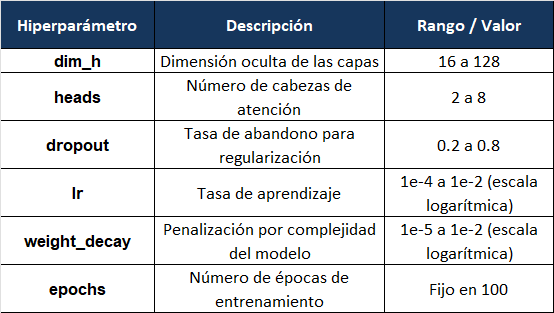

In [ ]:
# Fijar semilla para reproducibilidad
torch.manual_seed(1)

# Crear máscaras de entrenamiento, validación y prueba
num_nodes = data.num_nodes
perm = torch.randperm(num_nodes)
train_size = int(0.7 * num_nodes)
val_size = int(0.15 * num_nodes)

data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.val_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)

data.train_mask[perm[:train_size]] = True
data.val_mask[perm[train_size:train_size + val_size]] = True
data.test_mask[perm[train_size + val_size:]] = True

print(data)  # Verificar que las máscaras se hayan agregado correctamente

Data(x=[28281, 128], edge_index=[2, 185504], y=[28281], train_mask=[28281], val_mask=[28281], test_mask=[28281])


In [ ]:
def accuracy(y_pred, y_true):
    """Calcular la precisión."""
    return torch.sum(y_pred == y_true).item() / len(y_true)

In [ ]:
class GAT(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out, heads=8, dropout=0.6):
        super(GAT, self).__init__()
        self.gat1 = GATv2Conv(dim_in, dim_h, heads=heads, dropout=dropout)
        # Para la segunda capa, usualmente se usa heads=1 y concat=False para obtener las dimensiones correctas
        self.gat2 = GATv2Conv(dim_h * heads, dim_out, heads=1, concat=False, dropout=dropout)
        self.dropout = Dropout(p=dropout)

    def forward(self, x, edge_index):
        x = self.dropout(x)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = self.dropout(x)
        x = self.gat2(x, edge_index)
        return F.log_softmax(x, dim=1)

    def fit(self, data, epochs, lr, weight_decay):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=weight_decay)

        self.train()
        for epoch in range(epochs + 1):
            optimizer.zero_grad()
            out = self(data.x, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if epoch % 20 == 0:
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}% | '
                      f'Val Loss: {val_loss:.3f} | Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, data.edge_index)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

In [ ]:
def objective(trial: Trial):
    # Definir el espacio de búsqueda de hiperparámetros
    dim_h = trial.suggest_int('dim_h', 16, 128)
    heads = trial.suggest_int('heads', 2, 8)
    dropout = trial.suggest_float('dropout', 0.2, 0.8)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    epochs = 100  # Reducir el número de épocas durante la optimización

    # Crear el modelo con los hiperparámetros sugeridos
    model = GAT(dataset.num_features, dim_h, dataset.num_classes, heads=heads, dropout=dropout)

    # Entrenar el modelo
    model.fit(data, epochs=epochs, lr=lr, weight_decay=weight_decay)

    # Evaluar en el conjunto de validación
    model.eval()
    out = model(data.x, data.edge_index)
    criterion = torch.nn.CrossEntropyLoss()
    val_loss = criterion(out[data.val_mask], data.y[data.val_mask]).item()
    val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])

    # Registrar los hiperparámetros y las métricas en Optuna
    trial.set_user_attr("val_loss", val_loss)
    trial.set_user_attr("val_acc", val_acc)

    # Retornar la precisión de validación
    return val_acc

In [ ]:
def main():
    # Crear un estudio de Optuna
    sampler = TPESampler(seed=42)  # Semilla para reproducibilidad
    study = optuna.create_study(direction='maximize', sampler=sampler)

    # Ejecutar la optimización
    study.optimize(objective, n_trials=50, timeout=3600)  # Ajusta n_trials y timeout según tus necesidades

    print("Número de pruebas realizadas: ", len(study.trials))
    print("Mejor valor de precisión de validación: ", study.best_trial.value)
    print("Mejores hiperparámetros: ")
    for key, value in study.best_trial.params.items():
        print(f"  {key}: {value}")

    # Entrenar el modelo final con los mejores hiperparámetros
    best_params = study.best_trial.params
    final_model = GAT(
        dataset.num_features,
        best_params['dim_h'],
        dataset.num_classes,
        heads=best_params['heads'],
        dropout=best_params['dropout']
    )
    final_model.fit(
        data,
        epochs=200,  # Puedes ajustar este valor
        lr=best_params['lr'],
        weight_decay=best_params['weight_decay']
    )

    # Evaluar en el conjunto de prueba
    test_acc = final_model.test(data)
    print(f'GAT test accuracy: {test_acc*100:.2f}%')

if __name__ == "__main__":
    main()

[I 2024-11-06 00:45:39,649] A new study created in memory with name: no-name-469fa937-bfa3-4156-a59d-7da44b82bcdd


Epoch   0 | Train Loss: 2.440 | Train Acc: 50.54% | Val Loss: 2.344 | Val Acc: 49.65%
Epoch  20 | Train Loss: 0.993 | Train Acc: 52.99% | Val Loss: 0.906 | Val Acc: 53.89%
Epoch  40 | Train Loss: 0.761 | Train Acc: 54.30% | Val Loss: 0.812 | Val Acc: 55.42%
Epoch  60 | Train Loss: 0.718 | Train Acc: 54.02% | Val Loss: 0.738 | Val Acc: 55.23%
Epoch  80 | Train Loss: 0.713 | Train Acc: 55.01% | Val Loss: 0.735 | Val Acc: 56.08%
Epoch 100 | Train Loss: 0.703 | Train Acc: 55.29% | Val Loss: 0.702 | Val Acc: 55.68%


[I 2024-11-06 00:54:19,799] Trial 0 finished with value: 0.5999528524280999 and parameters: {'dim_h': 58, 'heads': 8, 'dropout': 0.6391963650868431, 'lr': 0.0015751320499779737, 'weight_decay': 2.9380279387035334e-05}. Best is trial 0 with value: 0.5999528524280999.


Epoch   0 | Train Loss: 10.957 | Train Acc: 50.91% | Val Loss: 10.703 | Val Acc: 51.04%
Epoch  20 | Train Loss: 2.001 | Train Acc: 53.15% | Val Loss: 1.957 | Val Acc: 54.31%
Epoch  40 | Train Loss: 1.295 | Train Acc: 53.77% | Val Loss: 1.221 | Val Acc: 55.42%
Epoch  60 | Train Loss: 1.274 | Train Acc: 51.31% | Val Loss: 1.717 | Val Acc: 51.27%
Epoch  80 | Train Loss: 1.036 | Train Acc: 50.03% | Val Loss: 0.999 | Val Acc: 51.04%
Epoch 100 | Train Loss: 0.978 | Train Acc: 49.98% | Val Loss: 1.003 | Val Acc: 49.95%


[I 2024-11-06 00:55:39,181] Trial 1 finished with value: 0.574964639321075 and parameters: {'dim_h': 33, 'heads': 2, 'dropout': 0.7197056874649612, 'lr': 0.0015930522616241021, 'weight_decay': 0.001331121608073689}. Best is trial 0 with value: 0.5999528524280999.


...

Epoch   0 | Train Loss: 2.065 | Train Acc: 50.76% | Val Loss: 2.120 | Val Acc: 52.24%
Epoch  20 | Train Loss: 0.764 | Train Acc: 54.21% | Val Loss: 0.759 | Val Acc: 54.01%
Epoch  40 | Train Loss: 0.719 | Train Acc: 54.95% | Val Loss: 0.737 | Val Acc: 56.32%
Epoch  60 | Train Loss: 0.695 | Train Acc: 55.80% | Val Loss: 0.694 | Val Acc: 56.86%
Epoch  80 | Train Loss: 0.693 | Train Acc: 56.17% | Val Loss: 0.683 | Val Acc: 57.64%
Epoch 100 | Train Loss: 0.690 | Train Acc: 56.79% | Val Loss: 0.692 | Val Acc: 57.21%


[I 2024-11-06 01:33:37,169] Trial 9 finished with value: 0.6148043375766148 and parameters: {'dim_h': 90, 'heads': 4, 'dropout': 0.5120408127066866, 'lr': 0.0012399967836846098, 'weight_decay': 3.585612610345396e-05}. Best is trial 7 with value: 0.6343705799151343.


Epoch   0 | Train Loss: 0.811 | Train Acc: 52.38% | Val Loss: 0.825 | Val Acc: 52.59%
Epoch  20 | Train Loss: 0.798 | Train Acc: 54.99% | Val Loss: 0.809 | Val Acc: 56.60%
Epoch  40 | Train Loss: 0.720 | Train Acc: 57.06% | Val Loss: 0.702 | Val Acc: 58.79%
Epoch  60 | Train Loss: 0.691 | Train Acc: 57.53% | Val Loss: 0.689 | Val Acc: 59.83%
Epoch  80 | Train Loss: 0.683 | Train Acc: 58.04% | Val Loss: 0.671 | Val Acc: 60.49%
Epoch 100 | Train Loss: 0.700 | Train Acc: 58.60% | Val Loss: 0.683 | Val Acc: 60.40%


[I 2024-11-06 01:47:37,995] Trial 10 finished with value: 0.6197548326261197 and parameters: {'dim_h': 126, 'heads': 6, 'dropout': 0.3500768364437636, 'lr': 0.00010862348973937149, 'weight_decay': 0.0008322724281704743}. Best is trial 7 with value: 0.6343705799151343.


Número de pruebas realizadas:  11
Mejor valor de precisión de validación:  0.6343705799151343
Mejores hiperparámetros: 
  dim_h: 107
  heads: 4
  dropout: 0.25860326840383036
  lr: 0.0023359635026261607
  weight_decay: 0.00020914981329035596
Epoch   0 | Train Loss: 0.939 | Train Acc: 53.48% | Val Loss: 0.868 | Val Acc: 55.54%
Epoch  20 | Train Loss: 0.678 | Train Acc: 57.77% | Val Loss: 0.671 | Val Acc: 59.10%
Epoch  40 | Train Loss: 0.666 | Train Acc: 60.32% | Val Loss: 0.665 | Val Acc: 61.46%
Epoch  60 | Train Loss: 0.658 | Train Acc: 61.11% | Val Loss: 0.663 | Val Acc: 60.02%
Epoch  80 | Train Loss: 0.651 | Train Acc: 61.84% | Val Loss: 0.662 | Val Acc: 61.55%
Epoch 100 | Train Loss: 0.647 | Train Acc: 62.15% | Val Loss: 0.654 | Val Acc: 61.93%
Epoch 120 | Train Loss: 0.640 | Train Acc: 62.93% | Val Loss: 0.655 | Val Acc: 62.02%
Epoch 140 | Train Loss: 0.634 | Train Acc: 63.79% | Val Loss: 0.661 | Val Acc: 62.31%
Epoch 160 | Train Loss: 0.628 | Train Acc: 63.95% | Val Loss: 0.662 | 

### MODELO 4 + OPTUNA V2

**Espacio de Hiperparametros**

A continuacion se muestran los hiperparametros que se iteran para la obtencion del mejor resultado:

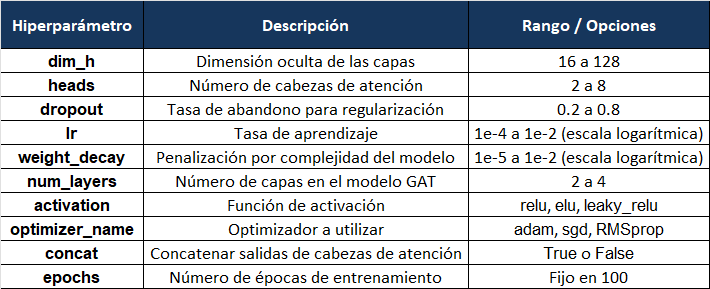

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv
from torch.nn import Linear, Dropout
import optuna
from optuna import Trial
from optuna.samplers import TPESampler

In [ ]:
# Bloque 1: Preparación de datos y máscaras
def prepare_data(data):

    torch.manual_seed(1)

    num_nodes = data.num_nodes
    perm = torch.randperm(num_nodes)
    train_size = int(0.7 * num_nodes)
    val_size = int(0.15 * num_nodes)

    data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    data.val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    data.train_mask[perm[:train_size]] = True
    data.val_mask[perm[train_size:train_size + val_size]] = True
    data.test_mask[perm[train_size + val_size:]] = True

    print(data)
    return data

In [ ]:
def accuracy(y_pred, y_true):
    """Calcular la precisión."""
    return torch.sum(y_pred == y_true).item() / len(y_true)


In [ ]:
class GAT(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out, num_layers=2, heads=8, activation='elu', dropout=0.6, concat=True):
        super(GAT, self).__init__()
        self.layers = torch.nn.ModuleList()
        self.num_layers = num_layers
        self.activation = getattr(F, activation) if activation != 'none' else lambda x: x
        self.dropout = Dropout(p=dropout)

        # Primera capa
        self.layers.append(GATv2Conv(dim_in, dim_h, heads=heads, dropout=dropout, concat=concat))

        # Capas intermedias
        for _ in range(num_layers - 2):
            in_channels = dim_h * heads if concat else dim_h
            self.layers.append(GATv2Conv(in_channels, dim_h, heads=heads, dropout=dropout, concat=concat))

        # Última capa
        in_channels = dim_h * heads if concat else dim_h
        self.layers.append(GATv2Conv(in_channels, dim_out, heads=1, concat=False, dropout=dropout))

    def forward(self, x, edge_index):
        x = self.dropout(x)
        for layer in self.layers[:-1]:
            x = layer(x, edge_index)
            x = self.activation(x)
            x = self.dropout(x)
        x = self.layers[-1](x, edge_index)
        return F.log_softmax(x, dim=1)

    def fit(self, data, epochs, lr, weight_decay, optimizer_name='adam'):
        criterion = torch.nn.CrossEntropyLoss()

        # Selección del optimizador con manejo correcto de nombres
        if optimizer_name.lower() == 'sgd':
            optimizer_class = torch.optim.SGD
        elif optimizer_name.lower() == 'rmsprop':
            optimizer_class = torch.optim.RMSprop
        else:
            optimizer_class = getattr(torch.optim, optimizer_name.capitalize())

        optimizer = optimizer_class(self.parameters(), lr=lr, weight_decay=weight_decay)

        self.train()
        for epoch in range(epochs + 1):
            optimizer.zero_grad()
            out = self(data.x, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if epoch % 20 == 0:
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}% | '
                      f'Val Loss: {val_loss:.3f} | Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, data.edge_index)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc


In [ ]:
# Bloque 4: Definición de la función objetivo para Optuna
def objective(trial: Trial, data, dataset):
    # Definir el espacio de búsqueda de hiperparámetros
    dim_h = trial.suggest_int('dim_h', 16, 128)
    heads = trial.suggest_int('heads', 2, 8)
    dropout = trial.suggest_float('dropout', 0.2, 0.8)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    num_layers = trial.suggest_int('num_layers', 2, 4)
    activation = trial.suggest_categorical('activation', ['relu', 'elu', 'leaky_relu'])
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'RMSprop'])
    concat = trial.suggest_categorical('concat', [True, False])
    epochs = 100  # Reducir el número de épocas durante la optimización

    # Crear el modelo con los hiperparámetros sugeridos
    model = GAT(
        dataset.num_features,
        dim_h,
        dataset.num_classes,
        num_layers=num_layers,
        heads=heads,
        activation=activation,
        dropout=dropout,
        concat=concat
    )

    # Entrenar el modelo
    model.fit(data, epochs=epochs, lr=lr, weight_decay=weight_decay, optimizer_name=optimizer_name)

    # Evaluar en el conjunto de validación
    model.eval()
    out = model(data.x, data.edge_index)
    criterion = torch.nn.CrossEntropyLoss()
    val_loss = criterion(out[data.val_mask], data.y[data.val_mask]).item()
    val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])

    # Registrar los hiperparámetros y las métricas en Optuna
    trial.set_user_attr("val_loss", val_loss)
    trial.set_user_attr("val_acc", val_acc)

    # Retornar la precisión de validación
    return val_acc

In [ ]:
# Bloque 5: Función principal
def main():

    # Crear un estudio de Optuna
    sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=sampler)

    # Ejecutar la optimización
    study.optimize(lambda trial: objective(trial, data, dataset), n_trials=50, timeout=3600)

    print("Número de pruebas realizadas: ", len(study.trials))
    print("Mejor valor de precisión de validación: ", study.best_trial.value)
    print("Mejores hiperparámetros: ")
    for key, value in study.best_trial.params.items():
        print(f"  {key}: {value}")

    # Entrenar el modelo final con los mejores hiperparámetros
    best_params = study.best_trial.params
    final_model = GAT(
        dataset.num_features,
        best_params['dim_h'],
        dataset.num_classes,
        num_layers=best_params['num_layers'],
        heads=best_params['heads'],
        activation=best_params['activation'],
        dropout=best_params['dropout'],
        concat=best_params['concat']
    )
    final_model.fit(
        data,
        epochs=200,
        lr=best_params['lr'],
        weight_decay=best_params['weight_decay'],
        optimizer_name=best_params['optimizer']
    )

    # Evaluar en el conjunto de prueba
    test_acc = final_model.test(data)
    print(f'GAT test accuracy: {test_acc*100:.2f}%')

if __name__ == "__main__":
    main()

[I 2024-11-07 00:29:43,134] A new study created in memory with name: no-name-496bf6fb-6db1-4827-9615-bde369424d24


Epoch   0 | Train Loss: 2.440 | Train Acc: 50.54% | Val Loss: 2.344 | Val Acc: 49.65%
Epoch  20 | Train Loss: 0.770 | Train Acc: 53.34% | Val Loss: 0.752 | Val Acc: 53.80%
Epoch  40 | Train Loss: 0.725 | Train Acc: 55.23% | Val Loss: 0.721 | Val Acc: 56.01%
Epoch  60 | Train Loss: 0.706 | Train Acc: 54.87% | Val Loss: 0.710 | Val Acc: 56.34%
Epoch  80 | Train Loss: 0.714 | Train Acc: 55.78% | Val Loss: 0.710 | Val Acc: 56.58%
Epoch 100 | Train Loss: 0.693 | Train Acc: 55.97% | Val Loss: 0.686 | Val Acc: 57.24%


[I 2024-11-07 00:38:48,823] Trial 0 finished with value: 0.6091466289486092 and parameters: {'dim_h': 58, 'heads': 8, 'dropout': 0.6391963650868431, 'lr': 0.0015751320499779737, 'weight_decay': 2.9380279387035334e-05, 'num_layers': 2, 'activation': 'elu', 'optimizer': 'RMSprop', 'concat': True}. Best is trial 0 with value: 0.6091466289486092.


Epoch   0 | Train Loss: 0.892 | Train Acc: 50.52% | Val Loss: 0.873 | Val Acc: 51.58%
Epoch  20 | Train Loss: 0.686 | Train Acc: 57.59% | Val Loss: 0.680 | Val Acc: 58.72%
Epoch  40 | Train Loss: 0.675 | Train Acc: 58.68% | Val Loss: 0.672 | Val Acc: 59.38%
Epoch  60 | Train Loss: 0.677 | Train Acc: 58.97% | Val Loss: 0.667 | Val Acc: 59.83%
Epoch  80 | Train Loss: 0.669 | Train Acc: 59.79% | Val Loss: 0.667 | Val Acc: 59.81%
Epoch 100 | Train Loss: 0.666 | Train Acc: 59.44% | Val Loss: 0.664 | Val Acc: 61.48%


[I 2024-11-07 00:41:12,837] Trial 1 finished with value: 0.6301272984441302 and parameters: {'dim_h': 36, 'heads': 3, 'dropout': 0.38254534577572263, 'lr': 0.0011207606211860567, 'weight_decay': 0.00019762189340280086, 'num_layers': 2, 'activation': 'relu', 'optimizer': 'RMSprop', 'concat': False}. Best is trial 1 with value: 0.6301272984441302.


...

Epoch   0 | Train Loss: 0.739 | Train Acc: 53.27% | Val Loss: 0.725 | Val Acc: 54.50%
Epoch  20 | Train Loss: 0.685 | Train Acc: 56.36% | Val Loss: 0.679 | Val Acc: 58.25%
Epoch  40 | Train Loss: 0.678 | Train Acc: 57.69% | Val Loss: 0.672 | Val Acc: 59.19%
Epoch  60 | Train Loss: 0.673 | Train Acc: 58.87% | Val Loss: 0.669 | Val Acc: 60.04%
Epoch  80 | Train Loss: 0.667 | Train Acc: 59.84% | Val Loss: 0.667 | Val Acc: 60.28%
Epoch 100 | Train Loss: 0.664 | Train Acc: 59.97% | Val Loss: 0.665 | Val Acc: 60.70%


[I 2024-11-07 01:25:39,121] Trial 7 finished with value: 0.6152758132956153 and parameters: {'dim_h': 18, 'heads': 2, 'dropout': 0.21885751141204057, 'lr': 0.0018742210985555703, 'weight_decay': 8.771380343280557e-05, 'num_layers': 3, 'activation': 'relu', 'optimizer': 'adam', 'concat': True}. Best is trial 1 with value: 0.6301272984441302.


Epoch   0 | Train Loss: 0.892 | Train Acc: 52.48% | Val Loss: 0.871 | Val Acc: 54.34%
Epoch  20 | Train Loss: 0.683 | Train Acc: 57.23% | Val Loss: 0.680 | Val Acc: 59.52%
Epoch  40 | Train Loss: 0.678 | Train Acc: 57.76% | Val Loss: 0.671 | Val Acc: 59.76%
Epoch  60 | Train Loss: 0.677 | Train Acc: 58.38% | Val Loss: 0.676 | Val Acc: 58.68%
Epoch  80 | Train Loss: 0.673 | Train Acc: 58.56% | Val Loss: 0.668 | Val Acc: 60.11%
Epoch 100 | Train Loss: 0.675 | Train Acc: 58.22% | Val Loss: 0.666 | Val Acc: 60.37%


[I 2024-11-07 01:40:31,601] Trial 8 finished with value: 0.6204620462046204 and parameters: {'dim_h': 121, 'heads': 7, 'dropout': 0.5800422539062542, 'lr': 0.005532496914298506, 'weight_decay': 0.0025764174425233167, 'num_layers': 2, 'activation': 'relu', 'optimizer': 'adam', 'concat': False}. Best is trial 1 with value: 0.6301272984441302.


Número de pruebas realizadas:  9
Mejor valor de precisión de validación:  0.6301272984441302
Mejores hiperparámetros: 
  dim_h: 36
  heads: 3
  dropout: 0.38254534577572263
  lr: 0.0011207606211860567
  weight_decay: 0.00019762189340280086
  num_layers: 2
  activation: relu
  optimizer: RMSprop
  concat: False
Epoch   0 | Train Loss: 0.982 | Train Acc: 48.44% | Val Loss: 1.008 | Val Acc: 47.57%
Epoch  20 | Train Loss: 0.689 | Train Acc: 57.15% | Val Loss: 0.683 | Val Acc: 59.31%
Epoch  40 | Train Loss: 0.679 | Train Acc: 58.61% | Val Loss: 0.684 | Val Acc: 59.03%
Epoch  60 | Train Loss: 0.671 | Train Acc: 59.05% | Val Loss: 0.668 | Val Acc: 60.28%
Epoch  80 | Train Loss: 0.668 | Train Acc: 59.47% | Val Loss: 0.672 | Val Acc: 60.70%
Epoch 100 | Train Loss: 0.665 | Train Acc: 60.24% | Val Loss: 0.668 | Val Acc: 60.28%
Epoch 120 | Train Loss: 0.667 | Train Acc: 59.17% | Val Loss: 0.661 | Val Acc: 60.25%
Epoch 140 | Train Loss: 0.666 | Train Acc: 60.04% | Val Loss: 0.667 | Val Acc: 61.24%


### Modelo : ACMII_GCN_PlusPlus : 64.93%


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import DeezerEurope
from torch_geometric.nn import GCNConv, SAGEConv, GraphConv
from sklearn.metrics import accuracy_score

# Configurar el dispositivo CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Cargar el dataset Deezer Europe y moverlo a CUDA si está disponible
dataset = DeezerEurope(root='data/DeezerEurope')
data = dataset[0].to(device)

# Crear máscaras de entrenamiento, validación y prueba
num_nodes = data.num_nodes
torch.manual_seed(1)  # Fijar semilla para reproducibilidad

# Dividir los nodos en 70% para entrenamiento, 15% para validación, y 15% para prueba
perm = torch.randperm(num_nodes)
train_size = int(0.7 * num_nodes)
val_size = int(0.15 * num_nodes)

data.train_mask = torch.zeros(num_nodes, dtype=torch.bool, device=device)
data.val_mask = torch.zeros(num_nodes, dtype=torch.bool, device=device)
data.test_mask = torch.zeros(num_nodes, dtype=torch.bool, device=device)

data.train_mask[perm[:train_size]] = True
data.val_mask[perm[train_size:train_size + val_size]] = True
data.test_mask[perm[train_size + val_size:]] = True

print(data)  # Verificar que las máscaras se hayan agregado correctamente

class ACMII_GCN_PlusPlus(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(ACMII_GCN_PlusPlus, self).__init__()
        self.conv1 = GraphConv(in_channels, hidden_channels, aggr='mean')
        self.conv2 = GraphConv(hidden_channels, hidden_channels, aggr='mean')
        self.fc = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.fc(x)
        return x

    @torch.no_grad()
    def test(self, data, mask):
        self.eval()
        out = self(data)
        pred = out.argmax(dim=1)
        acc = accuracy_score(data.y[mask].cpu(), pred[mask].cpu())
        return acc

# Crear el modelo y optimizador, y mover el modelo a CUDA si está disponible
model = ACMII_GCN_PlusPlus(data.num_features, hidden_channels=64, out_channels=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Función de entrenamiento
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# Entrenamiento del modelo
for epoch in range(1, 101):
    loss = train()
    acc_train = model.test(data, data.train_mask)  # Precisión en el conjunto de entrenamiento
    acc_val = model.test(data, data.val_mask)  # Precisión en el conjunto de validación
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train Acc: {acc_train*100:.2f}%, Val Acc: {acc_val*100:.2f}%')

# Llamada final para imprimir la precisión de prueba
acc_test = model.test(data, data.test_mask)
print(f'\nTest accuracy: {acc_test*100:.2f}%')

Data(x=[28281, 128], edge_index=[2, 185504], y=[28281], train_mask=[28281], val_mask=[28281], test_mask=[28281])
Epoch: 001, Loss: 0.7052, Train Acc: 56.75%, Val Acc: 58.96%
Epoch: 002, Loss: 0.6829, Train Acc: 60.93%, Val Acc: 60.54%
Epoch: 003, Loss: 0.6789, Train Acc: 62.47%, Val Acc: 63.11%
Epoch: 004, Loss: 0.6624, Train Acc: 62.05%, Val Acc: 63.08%
Epoch: 005, Loss: 0.6517, Train Acc: 63.40%, Val Acc: 63.74%
Epoch: 006, Loss: 0.6466, Train Acc: 65.65%, Val Acc: 65.13%
Epoch: 007, Loss: 0.6388, Train Acc: 66.11%, Val Acc: 64.80%
Epoch: 008, Loss: 0.6322, Train Acc: 66.45%, Val Acc: 65.16%
Epoch: 009, Loss: 0.6260, Train Acc: 66.59%, Val Acc: 64.95%
Epoch: 010, Loss: 0.6210, Train Acc: 66.60%, Val Acc: 65.23%
Epoch: 011, Loss: 0.6196, Train Acc: 67.06%, Val Acc: 65.58%
Epoch: 012, Loss: 0.6150, Train Acc: 67.09%, Val Acc: 65.35%
Epoch: 013, Loss: 0.6151, Train Acc: 67.36%, Val Acc: 65.42%
Epoch: 014, Loss: 0.6110, Train Acc: 67.26%, Val Acc: 65.30%
Epoch: 015, Loss: 0.6088, Train A